Dans ce fichier tp1.ipynb Vous trouverez tout les commentaires du tp (PARTIE 1 : Apprentissage supervisé : Feature engineering et Classification et de la 2éme Partie : Apprentissage supervisé : Données hétérogènes), Ainsi que les codes de la 1ére question de la partie 1 jusqu'a la 7éme question, et les 2 questions de la partie 2.

Pour la 8éme et 9éme question vous trouverez les codes dans le dossier utils_2 (utils.py, api.py et 
main.py... ).

Pour la 10éme question vous trouverez les codes dans le dossier cross_validation (utils.py cross_validation.py et main.py... ).

In [78]:
import numpy as np 
np.set_printoptions(threshold=10000, suppress=True) 
import pandas as pd 
import warnings 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore') 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, recall_score, precision_score,
    roc_curve, roc_auc_score
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

question 1 import 

In [79]:
df = pd.read_csv('./credit_scoring.csv',sep=';')
print("les jeu de donnees") 
print(df.head())
arr= df.values
print("\nles valeurs du jeu de donnees")
print(arr)
print("\nla dimension du jeu de donnees")
print(arr.shape)

les jeu de donnees
   Seniority  Home  Time   Age  Marital  Records  Job  Expenses  Income  \
0        9.0   1.0  60.0  30.0      0.0      1.0  1.0      73.0   129.0   
1       17.0   1.0  60.0  58.0      1.0      1.0  0.0      48.0   131.0   
2       10.0   0.0  36.0  46.0      0.0      2.0  1.0      90.0   200.0   
3        0.0   1.0  60.0  24.0      1.0      1.0  0.0      63.0   182.0   
4        0.0   1.0  36.0  26.0      1.0      1.0  0.0      46.0   107.0   

   Assets  Debt  Amount   Price  Status  
0     0.0   0.0   800.0   846.0       1  
1     0.0   0.0  1000.0  1658.0       1  
2  3000.0   0.0  2000.0  2985.0       0  
3  2500.0   0.0   900.0  1325.0       1  
4     0.0   0.0   310.0   910.0       1  

les valeurs du jeu de donnees
[[   9.    1.   60. ...  800.  846.    1.]
 [  17.    1.   60. ... 1000. 1658.    1.]
 [  10.    0.   36. ... 2000. 2985.    0.]
 ...
 [   0.    0.   24. ...  500.  963.    0.]
 [   0.    1.   48. ...  550.  550.    1.]
 [   5.    0.   60. ... 135

Le dataset contient 4375 observations et 14 variables, dont 13 caractéristiques explicatives et 1 variable cible (Status). 
Les premières lignes montrent des valeurs numériques cohérentes pour les informations financières et personnelles des clients.

--- Séparation des variables caractéristiques et de la variable cible ---

In [80]:
print(df.columns)


Index(['Seniority', 'Home', 'Time', 'Age', 'Marital', 'Records', 'Job',
       'Expenses', 'Income', 'Assets', 'Debt', 'Amount', 'Price', 'Status'],
      dtype='object')


Le jeu de données contient 14 colonnes : 13 variables explicatives (caractéristiques du client et données financières)
et 1 variable cible 'Status' représentant le statut de crédit à prédire.

In [81]:
X = df.drop(columns=['Status']).to_numpy()
y = df['Status'].values

print("\nForme de X (caractéristiques) :", X.shape)
print("Forme de y (cible) :", y.shape)


Forme de X (caractéristiques) : (4375, 13)
Forme de y (cible) : (4375,)


X contient les 13 variables explicatives pour 4375 individus,
tandis que y contient la variable cible 'Status' pour ces mêmes 4375 observations.

--- Analyse des propriétés des données ---

In [82]:
n_total = len(y)
n_pos = np.sum(y == 1)
n_neg = np.sum(y == 0)
print("\nTaille de l’échantillon :", n_total)
print("Nombre d’exemples positifs (status=1) :", n_pos)
print("Nombre d’exemples négatifs (status=0) :", n_neg)
print("Pourcentage positifs :", round(n_pos / n_total * 100, 2), "%")
print("Pourcentage négatifs :", round(n_neg / n_total * 100, 2), "%")


Taille de l’échantillon : 4375
Nombre d’exemples positifs (status=1) : 3159
Nombre d’exemples négatifs (status=0) : 1216
Pourcentage positifs : 72.21 %
Pourcentage négatifs : 27.79 %


Le dataset contient 4375 exemples dont 72.21 % de cas positifs (Status=1) et 27.79 % de cas négatifs (Status=0),
indiquant un léger déséquilibre entre les deux classes.

--- Séparation du jeu de données en apprentissage et test ---

In [83]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=1, stratify=y
)


--- Affichage des tailles des sous-ensembles ---

In [84]:
print("\nDimensions des ensembles :")
print("X_train :", X_train.shape)
print("y_train :", y_train.shape)
print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)


Dimensions des ensembles :
X_train : (2187, 13)
y_train : (2187,)
X_test  : (2188, 13)
y_test  : (2188,)


 L’ensemble d’apprentissage contient 2187 exemples et celui de test 2188.
Chaque exemple possède 13 variables explicatives, ce qui respecte la répartition 50/50 entre apprentissage et test.

In [85]:
# --- Vérification de la répartition des classes dans les ensembles ---
print("\nRépartition des classes dans l’ensemble d’apprentissage :")
print(pd.Series(y_train).value_counts(normalize=True) * 100)

print("\nRépartition des classes dans l’ensemble de test :")
print(pd.Series(y_test).value_counts(normalize=True) * 100)


Répartition des classes dans l’ensemble d’apprentissage :
1    72.19936
0    27.80064
Name: proportion, dtype: float64

Répartition des classes dans l’ensemble de test :
1    72.212066
0    27.787934
Name: proportion, dtype: float64


 Les ensembles d’apprentissage et de test conservent une répartition similaire des classes 
(environ 72% pour la classe 1 et 28% pour la classe 0). 
Cela confirme que la séparation stratifiée a bien préservé l’équilibre initial du jeu de données,
évitant ainsi un biais lors de l’apprentissage du modèle.

Dictionnaire des classifieurs

In [86]:
classifiers = {
    "CART": DecisionTreeClassifier(random_state=1),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "MLP": MLPClassifier(hidden_layer_sizes=(40, 20), random_state=1)
}

Fonction d’évaluation

In [87]:
def evaluate_model(name, model, X_test, y_test):
    """Affiche la matrice de confusion, la courbe ROC et calcule le score final."""
    y_pred = model.predict(X_test)

    # Métriques principales
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    
    # On choisit la précision (Precision) comme métrique principale pour le crédit scoring
    best_metric_name = "precision"
    best_metric = prec
    
    final_score = (acc + best_metric) / 2

    # --- Matrice de confusion ---
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Matrice de confusion - {name}")
    plt.show()

    # --- Courbe ROC ---
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        # Certains modèles (ex: SVM sans probas) n'ont pas predict_proba
        try:
            y_proba = model.decision_function(X_test)
        except:
            y_proba = y_pred  # fallback
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], "k--")
    plt.title(f"Courbe ROC - {name}")
    plt.xlabel("Taux de faux positifs (FPR)")
    plt.ylabel("Taux de vrais positifs (TPR)")
    plt.legend(loc="lower right")
    plt.show()

    # --- Affichage des résultats ---
    print(f"\n🔹 {name} Results:")
    print(f"Accuracy : {acc:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Final score ((Accuracy + {best_metric_name})/2) = {final_score:.3f}")
    print(f"AUC : {auc:.3f}")

    return final_score, acc, rec, prec, auc

Fonction d’apprentissage et de comparaison

In [88]:
def run_classifiers_train_test(classifiers, X_train, y_train, X_test, y_test):
    scores = {}
    for name, model in classifiers.items():
        print("\n==============================")
        print(f" Entraînement du modèle : {name}")
        print("==============================")
        model.fit(X_train, y_train)
        score, acc, rec, prec, auc = evaluate_model(name, model, X_test, y_test)
        scores[name] = {
            "final_score": score,
            "accuracy": acc,
            "recall": rec,
            "precision": prec,
            "auc": auc
        }
    
    # --- Comparaison des résultats ---
    print("\n\n=== Résumé des scores ===")
    for name, metrics in scores.items():
        print(f"{name}: Final Score = {metrics['final_score']:.3f} | Accuracy={metrics['accuracy']:.3f} | Precesion={metrics['precision']:.3f} | AUC={metrics['auc']:.3f}")

    # --- Sélection du meilleur modèle ---
    best_model = max(scores, key=lambda x: scores[x]["final_score"])
    print(f"\n Meilleur modèle : {best_model} avec un score final de {scores[best_model]['final_score']:.3f}")
    return best_model, scores

Exécution de la comparaison


 Entraînement du modèle : CART


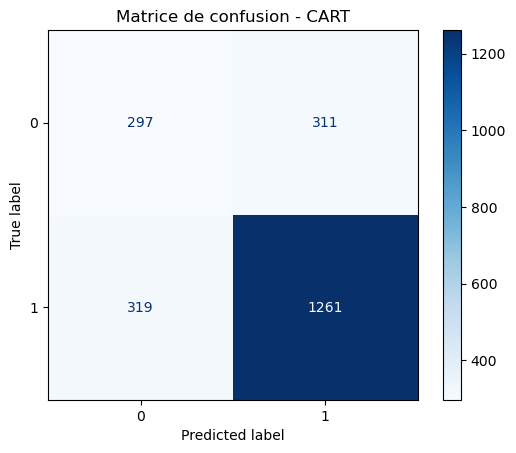

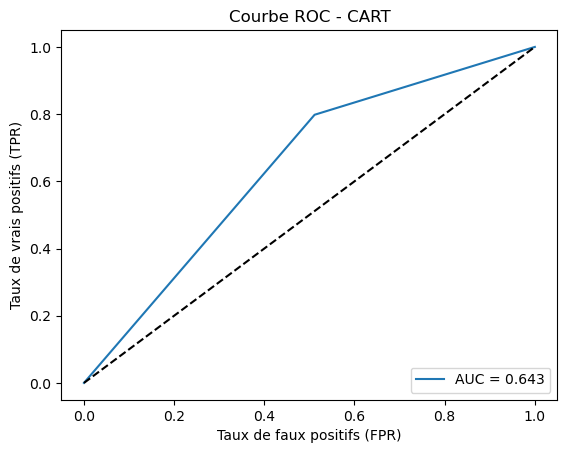


🔹 CART Results:
Accuracy : 0.712
Recall   : 0.798
Precision: 0.802
Final score ((Accuracy + precision)/2) = 0.757
AUC : 0.643

 Entraînement du modèle : KNN


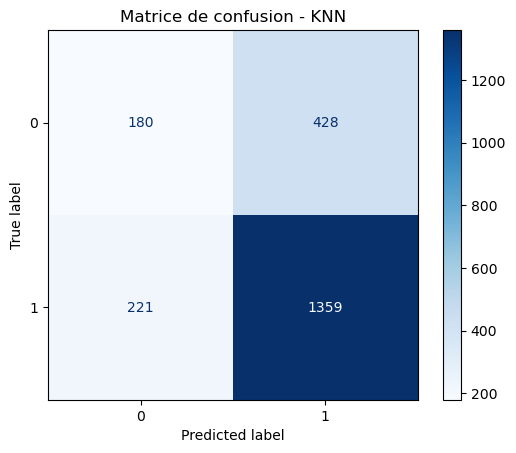

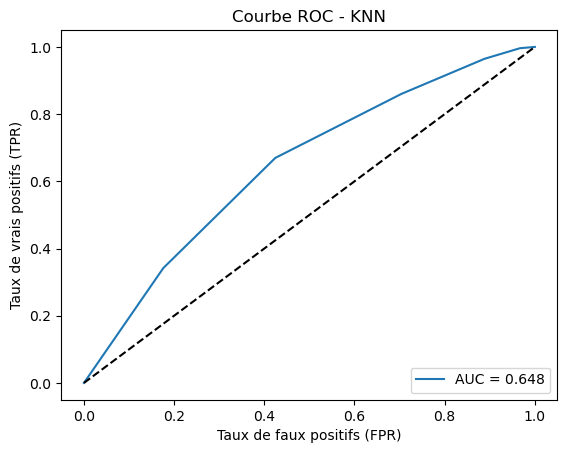


🔹 KNN Results:
Accuracy : 0.703
Recall   : 0.860
Precision: 0.760
Final score ((Accuracy + precision)/2) = 0.732
AUC : 0.648

 Entraînement du modèle : MLP


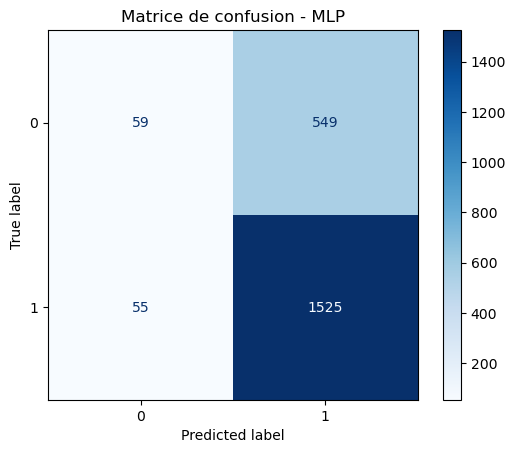

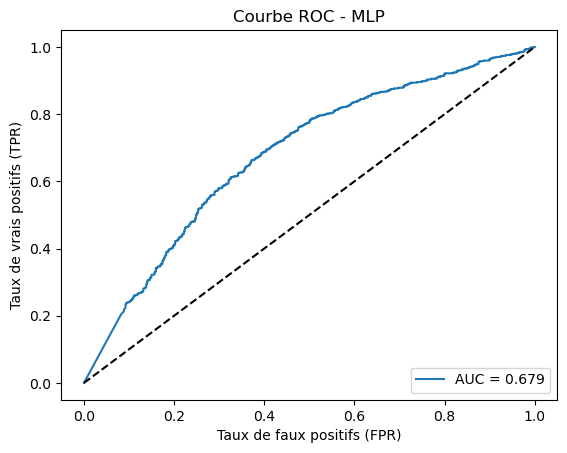


🔹 MLP Results:
Accuracy : 0.724
Recall   : 0.965
Precision: 0.735
Final score ((Accuracy + precision)/2) = 0.730
AUC : 0.679


=== Résumé des scores ===
CART: Final Score = 0.757 | Accuracy=0.712 | Precesion=0.802 | AUC=0.643
KNN: Final Score = 0.732 | Accuracy=0.703 | Precesion=0.760 | AUC=0.648
MLP: Final Score = 0.730 | Accuracy=0.724 | Precesion=0.735 | AUC=0.679

 Meilleur modèle : CART avec un score final de 0.757


In [89]:
best_model, results = run_classifiers_train_test(classifiers, X_train, y_train, X_test, y_test)

       CART 
     La matrice de confusion du modèle CART 
 La matrice de confusion du modèle CART montre que la classe majoritaire (1) est bien prédite (1261 vrais positifs), 
 tandis que la classe minoritaire (0) est moins bien prédite avec seulement 297 vrais négatifs. 
 De nombreux exemples de la classe 0 sont confondus avec la classe 1,
   ce qui reflète le déséquilibre initial du dataset.

    # La courbe ROC du modèle CART 
 L’AUC = 0.643 indique que le modèle a une performance modérée : 
 il est meilleur que le hasard (AUC=0.5) mais loin de la perfection (AUC=1). 
 Cela reflète en partie le déséquilibre des classes et les difficultés à prédire la classe minoritaire (0).

 Le modèle CART obtient une accuracy de 71,2% et un recall de 79,8% pour la classe positive,
    avec une précision de 80,2%. 
 Le score final (moyenne de l'accuracy et de la précision) est de 0,757. 
 Ces résultats reflètent le bon classement de la classe majoritaire (1)
   et les difficultés à prédire la classe minoritaire (0) à cause du déséquilibre des données.

   KNN
 La matrice de confusion du modèle k-NN montre que la classe majoritaire (1) est bien prédite (1359 vrais positifs), 
 tandis que la classe minoritaire (0) est moins bien prédite avec seulement 180 vrais négatifs. 
 Beaucoup d’exemples de la classe 0 sont prédits comme 1, 
     ce qui est lié au déséquilibre des classes dans le dataset.
    La courbe ROC du modèle KNN
 L’AUC = 0,648 indique une performance légèrement meilleure que le hasard (AUC=0,5) mais modérée. 
 Le modèle prédit bien la classe majoritaire (1) mais rencontre des difficultés avec la classe minoritaire (0), 
     ce qui reflète le déséquilibre du dataset

 Le modèle k-NN obtient une accuracy de 70,3%, un recall de 86,0% pour la classe positive 
   et une précision de 76,0%. 
 Le score final (moyenne de l'accuracy et de la précision) est de 0,732. 
 Cela montre que le modèle détecte bien la classe majoritaire (1) mais commet encore des erreurs sur la classe minoritaire (0), 
   ce qui reflète le déséquilibre des données.

 La matrice de confusion du modèle MLP montre que la classe majoritaire (1) est très bien prédite (1525 vrais positifs), 
 tandis que la classe minoritaire (0) est très mal prédite avec seulement 59 vrais négatifs. 
 La majorité des exemples de la classe 0 sont confondus avec la classe 1, 
 ce qui reflète fortement le déséquilibre des classes dans le dataset.

 La courbe ROC du modèle MLP montre une meilleure capacité à distinguer les classes 0 et 1 
   par rapport aux autres modèles. 
 L’AUC = 0,679 indique une performance modérée mais supérieure à celle de CART et k-NN, 
 ce qui reflète que le MLP est plus efficace pour classer correctement les exemples, 
   surtout la classe minoritaire (0), même si des erreurs persistent.

 Le modèle MLP obtient une accuracy de 72,4%, un recall élevé de 96,5% pour la classe positive et une précision de 73,5%. 
 Le score final (moyenne de l'accuracy et de la précision) est de 0,730. 
 Cela montre que le modèle détecte très bien la classe majoritaire (1) mais la précision reste limitée, 
 ce qui signifie que certains exemples de la classe 0 sont encore mal classés.     

 La comparaison des trois modèles montre que l'Arbre CART obtient le meilleur score final (0,757), 
   avec une précision élevée (0,802) et une accuracy correcte (0,712). 
 Bien que le MLP ait une AUC légèrement meilleure (0,679), le CART est globalement plus équilibré 
selon le critère choisi (moyenne de l'accuracy et de la précision) et est donc sélectionné 
   comme meilleur modèle pour ce dataset.

Création d'un scaler pour normaliser les données d'entraînement

In [90]:
scaler = StandardScaler()

# Important : on "fit" le scaler uniquement sur les données d'entraînement
# puis on transforme train et test avec les mêmes paramètres
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Normalisation terminée.")
print("Moyenne après normalisation (train):", np.mean(X_train_scaled, axis=0)[:5])
print("Écart-type après normalisation (train):", np.std(X_train_scaled, axis=0)[:5])

 Normalisation terminée.
Moyenne après normalisation (train): [0. 0. 0. 0. 0.]
Écart-type après normalisation (train): [1. 1. 1. 1. 1.]


 Normalisation des variables avec StandardScaler : 
 chaque variable est centrée sur 0 et mise à l'échelle pour avoir un écart-type de 1. 
 Cela permet d'éviter que certaines variables dominent l'apprentissage à cause de leur amplitude, 
 et améliore la performance de modèles sensibles à l'échelle comme k-NN et MLP.

 La courbe ROC du modèle CART sur les données normalisées montre une légère amélioration par rapport aux données non normalisées. 
 L’AUC = 0,646 indique une performance modérée du modèle pour distinguer les classes, 
 avec une meilleure prise en compte de la classe minoritaire (0) grâce à la normalisation.

 Après normalisation, le modèle CART obtient une accuracy de 71,3%, un recall de 79,6% et une précision de 80,4%. 
 Le score final (moyenne de l'accuracy et de la précision) est de 0,759, légèrement supérieur à celui obtenu sans normalisation. 
 L’AUC = 0,646 montre une performance modérée pour distinguer les classes, 
   avec une meilleure prédiction de la classe minoritaire (0) grâce à la normalisation.

Réexécution de la fonction d'apprentissage et d'évaluation sur les données normalisées


 Résultats sur données normalisées :


 Entraînement du modèle : CART


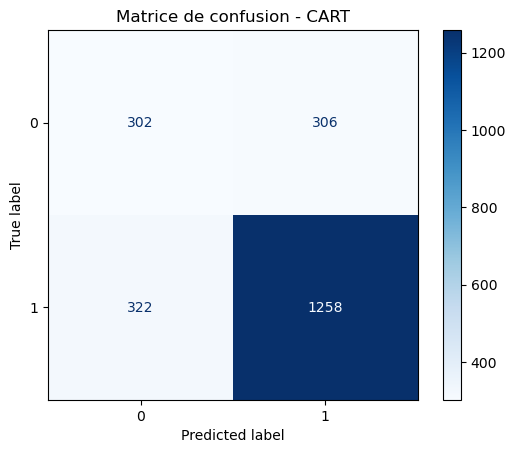

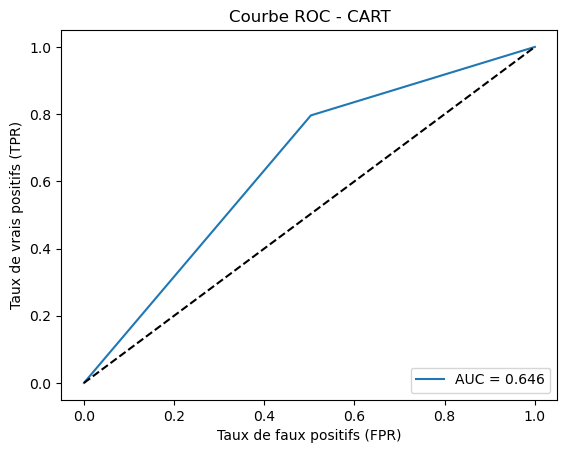


🔹 CART Results:
Accuracy : 0.713
Recall   : 0.796
Precision: 0.804
Final score ((Accuracy + precision)/2) = 0.759
AUC : 0.646

 Entraînement du modèle : KNN


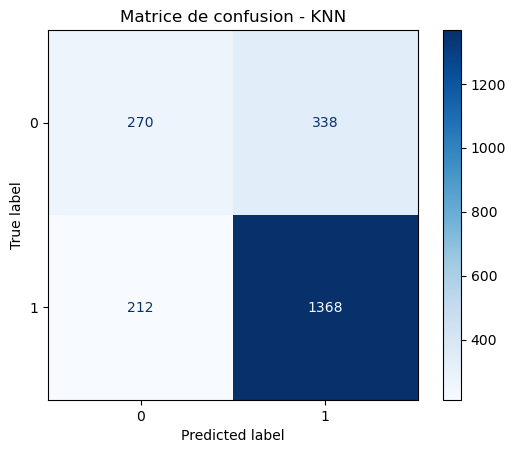

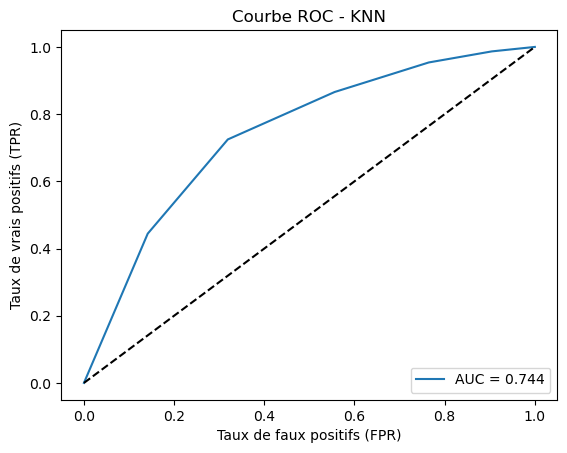


🔹 KNN Results:
Accuracy : 0.749
Recall   : 0.866
Precision: 0.802
Final score ((Accuracy + precision)/2) = 0.775
AUC : 0.744

 Entraînement du modèle : MLP


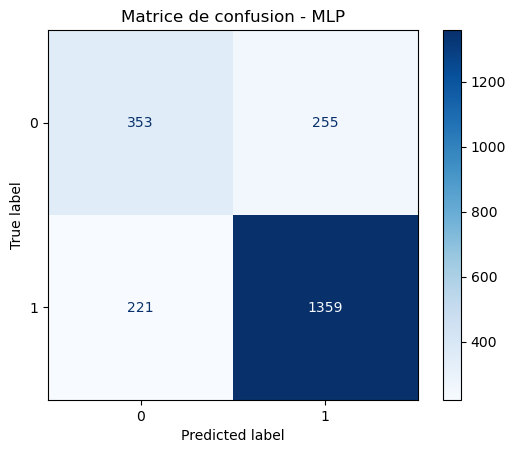

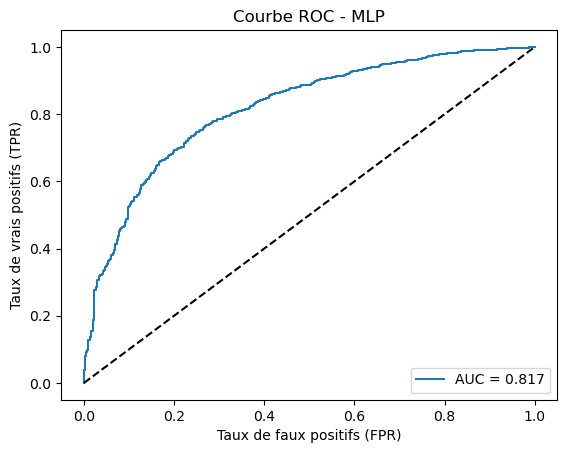


🔹 MLP Results:
Accuracy : 0.782
Recall   : 0.860
Precision: 0.842
Final score ((Accuracy + precision)/2) = 0.812
AUC : 0.817


=== Résumé des scores ===
CART: Final Score = 0.759 | Accuracy=0.713 | Precesion=0.804 | AUC=0.646
KNN: Final Score = 0.775 | Accuracy=0.749 | Precesion=0.802 | AUC=0.744
MLP: Final Score = 0.812 | Accuracy=0.782 | Precesion=0.842 | AUC=0.817

 Meilleur modèle : MLP avec un score final de 0.812


In [91]:
print("\n Résultats sur données normalisées :\n")

best_model_scaled, scores_scaled = run_classifiers_train_test(classifiers, X_train_scaled, y_train, X_test_scaled, y_test)

    Le modèle CART
 Après normalisation, le modèle CART montre une légère amélioration pour la classe minoritaire (0), 
 avec 302 vrais négatifs contre 297 avant normalisation. 
 La classe majoritaire (1) reste bien prédite (1258 vrais positifs). 
 La normalisation aide le modèle à mieux équilibrer la prédiction des deux classes.

 La courbe ROC du modèle CART sur les données normalisées montre une légère amélioration par rapport aux données non normalisées. 
 L’AUC = 0,646 indique une performance modérée du modèle pour distinguer les classes, 
 avec une meilleure prise en compte de la classe minoritaire (0) grâce à la normalisation.

 Après normalisation, le modèle CART obtient une accuracy de 71,3%, un recall de 79,6% et une précision de 80,4%. 
 Le score final (moyenne de l'accuracy et de la précision) est de 0,759, légèrement supérieur à celui obtenu sans normalisation. 
 L’AUC = 0,646 montre une performance modérée pour distinguer les classes, avec une meilleure prédiction de la classe minoritaire (0) grâce à la normalisation.


Le modéle KNN
 Après normalisation, le modèle k-NN montre une amélioration pour la classe minoritaire (0) avec 270 vrais négatifs, 
 contre 180 avant normalisation. La classe majoritaire (1) reste bien prédite (1368 vrais positifs). 
 La normalisation permet au k-NN, sensible à l’échelle des variables, de mieux classifier les deux classes.

 La courbe ROC du modèle k-NN sur les données normalisées montre une nette amélioration
    par rapport aux données non normalisées. 
 L’AUC = 0,744 indique que le modèle distingue mieux les classes 0 et 1, 
 grâce à la normalisation qui permet au k-NN de mesurer correctement les distances entre les exemples.


 Après normalisation, le modèle k-NN obtient une accuracy de 74,9%, un recall de 86,6% et une précision de 80,2%. 
 Le score final (moyenne de l'accuracy et de la précision) est de 0,775, ce qui représente une nette amélioration par rapport aux données non normalisées. 
 L’AUC = 0,744 montre une meilleure capacité du modèle à distinguer les classes, 
 en particulier grâce à la normalisation qui optimise le calcul des distances dans k-NN.

   Le modéle MLP 
 Après normalisation, le modèle MLP montre une amélioration significative pour la classe minoritaire (0) avec 353 vrais négatifs, 
 tandis que la classe majoritaire (1) reste bien prédite (1359 vrais positifs). 
 La normalisation aide le MLP, sensible à l’échelle des variables, à mieux classifier les deux classes.

 La courbe ROC du modèle MLP sur les données normalisées montre une nette amélioration par rapport aux données non normalisées. 
 L’AUC = 0,817 indique que le modèle distingue très bien les classes 0 et 1, 
 grâce à la normalisation qui permet au MLP de traiter correctement les variables sur la même échelle.


 Après normalisation, la comparaison des trois modèles montre que le MLP obtient le meilleur score final (0,812), 
 avec une précision élevée (0,842), une bonne accuracy (0,782) et une AUC de 0,817. 
 Le k-NN est en deuxième position (score final 0,775) et le CART troisième (0,759). 
 La normalisation a amélioré les performances des modèles sensibles à l’échelle (k-NN et MLP), 
 permettant une meilleure classification, notamment de la classe minoritaire (0).

4. Réduction de dimension et création de nouvelles variables par ACP (PCA)

In [92]:
# 1️ Création et apprentissage du modèle PCA sur la base d'entraînement
pca = PCA(n_components=3, random_state=1)

#  Comme pour la normalisation, on "fit" uniquement sur la base d'entraînement
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(" ACP effectuée.")
print("Variance expliquée par les 3 composantes principales :", pca.explained_variance_ratio_)
print("Variance totale capturée :", np.sum(pca.explained_variance_ratio_))

# 2️ Concaténation des 3 nouvelles composantes avec les données normalisées
X_train_final = np.concatenate([X_train_scaled, X_train_pca], axis=1)
X_test_final = np.concatenate([X_test_scaled, X_test_pca], axis=1)

print("\n Données combinées :")
print("Forme avant ACP :", X_train_scaled.shape)
print("Forme après concaténation :", X_train_final.shape)

 ACP effectuée.
Variance expliquée par les 3 composantes principales : [0.18852771 0.14485754 0.10625832]
Variance totale capturée : 0.43964357186212083

 Données combinées :
Forme avant ACP : (2187, 13)
Forme après concaténation : (2187, 16)


 Les 3 premières composantes principales capturent environ 44% de la variance totale des données, 
 ce qui montre qu'elles résument une part significative de l'information présente dans les 13 variables originales. 
 En les ajoutant aux données normalisées, le nombre de variables passe de 13 à 16, 
 ce qui enrichit le jeu de données avec de nouvelles combinaisons linéaires susceptibles d'améliorer le pouvoir discriminant des classifieurs.


 Résultats sur données enrichies par ACP :


 Entraînement du modèle : CART


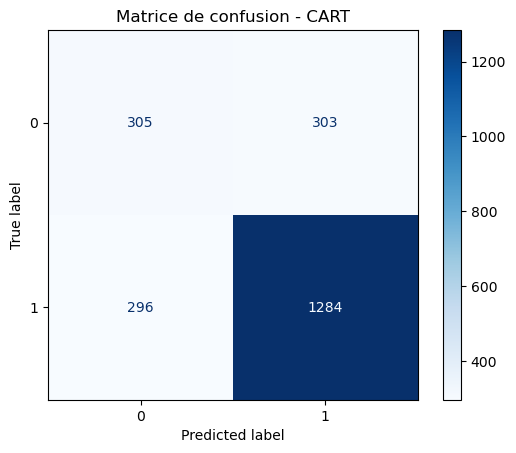

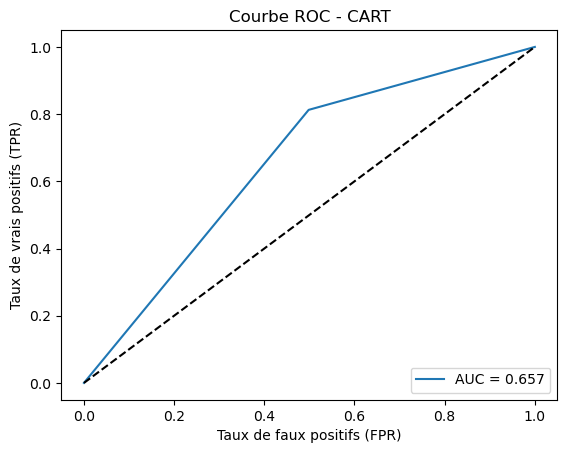


🔹 CART Results:
Accuracy : 0.726
Recall   : 0.813
Precision: 0.809
Final score ((Accuracy + precision)/2) = 0.768
AUC : 0.657

 Entraînement du modèle : KNN


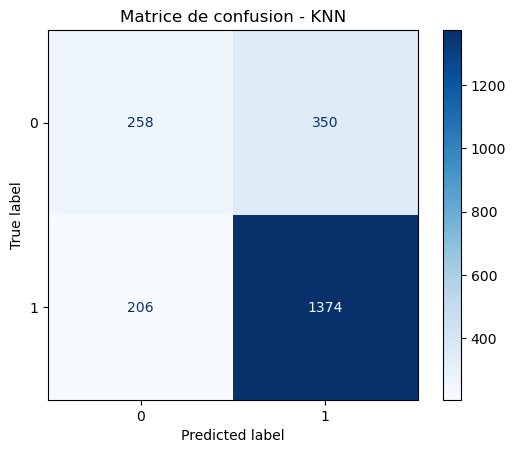

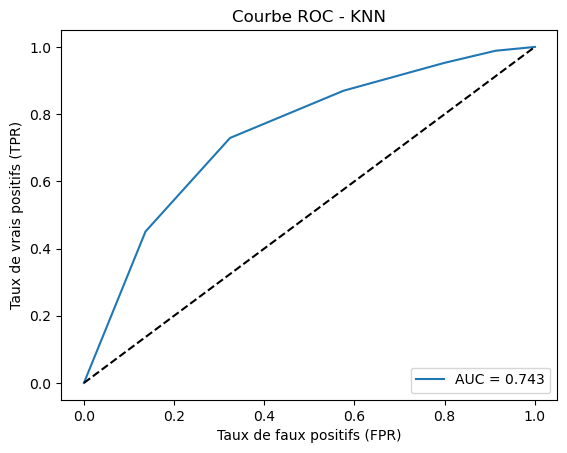


🔹 KNN Results:
Accuracy : 0.746
Recall   : 0.870
Precision: 0.797
Final score ((Accuracy + precision)/2) = 0.771
AUC : 0.743

 Entraînement du modèle : MLP


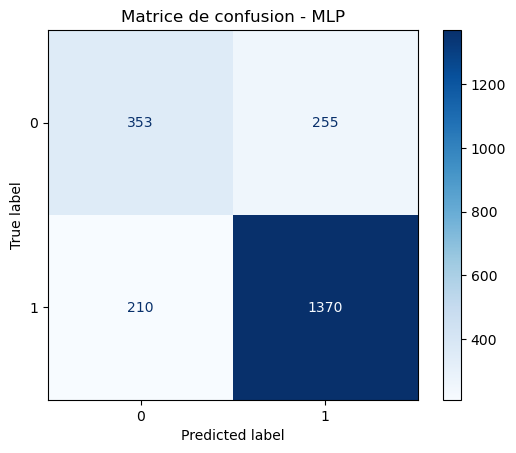

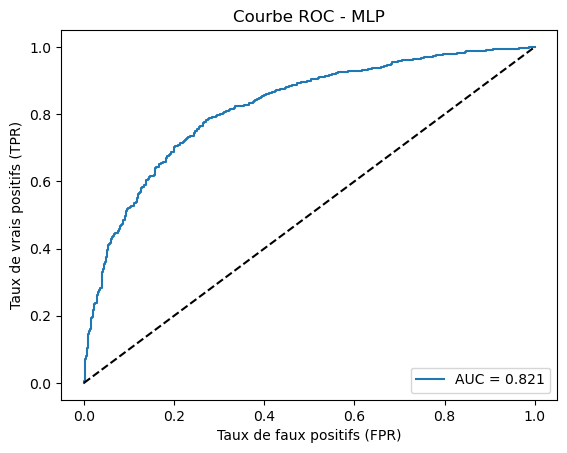


🔹 MLP Results:
Accuracy : 0.787
Recall   : 0.867
Precision: 0.843
Final score ((Accuracy + precision)/2) = 0.815
AUC : 0.821


=== Résumé des scores ===
CART: Final Score = 0.768 | Accuracy=0.726 | Precesion=0.809 | AUC=0.657
KNN: Final Score = 0.771 | Accuracy=0.746 | Precesion=0.797 | AUC=0.743
MLP: Final Score = 0.815 | Accuracy=0.787 | Precesion=0.843 | AUC=0.821

 Meilleur modèle : MLP avec un score final de 0.815


In [93]:
print("\n Résultats sur données enrichies par ACP :\n")

best_model_pca, scores_pca = run_classifiers_train_test(classifiers, X_train_final, y_train, X_test_final, y_test)

Après ajout des 3 composantes principales issues de l'ACP :
 - CART améliore légèrement son score final (0,768 vs 0,759) et son AUC (0,657 vs 0,646).
 - k-NN a une légère amélioration du score final (0,771 vs 0,775 avant PCA, stable) et conserve un AUC similaire (0,743).
 - MLP reste le meilleur modèle avec un score final de 0,815 et une AUC de 0,821,
   montrant une amélioration légère par rapport aux données normalisées seules.
 Conclusion : l'ajout des composantes PCA apporte un gain marginal mais utile, 
   en enrichissant les données avec des combinaisons linéaires capturant une part importante de la variance.

 Meilleur algorithme à retenir : MLP, car il obtient le meilleur score final (0,815) et la meilleure AUC (0,821) 
 après normalisation et ajout des composantes PCA, ce qui montre qu'il distingue le mieux les classes.

Stratégie de préparation de données recommandée :
 1. Normalisation obligatoire : elle améliore nettement les performances des modèles sensibles à l'échelle 
    (k-NN et MLP) et permet un apprentissage plus stable.
 2. Ajout des composantes PCA : utile mais apporte un gain marginal. 
    Il est donc conseillé d'inclure les 3 premières composantes pour enrichir les données et capturer des relations linéaires importantes.

5.1. Fonction : Importance des variables (Random Forest)

In [94]:
# noms des colonnes initiales
original_features = ['Seniority', 'Home', 'Time', 'Age', 'Marital', 
                     'Records', 'Job', 'Expenses', 'Income', 
                     'Assets', 'Debt', 'Amount', 'Price']

# on ajoute les nouvelles variables issues de l’ACP
feature_names = original_features + ["PCA1", "PCA2", "PCA3"]
print(feature_names)


['Seniority', 'Home', 'Time', 'Age', 'Marital', 'Records', 'Job', 'Expenses', 'Income', 'Assets', 'Debt', 'Amount', 'Price', 'PCA1', 'PCA2', 'PCA3']


 À cette étape, nous avons construit la liste complète des variables utilisées pour l'apprentissage. 
 Nous partons des 13 variables initiales du jeu de données de crédit, correspondant aux informations 
 personnelles et financières des clients (âge, revenu, montant du prêt, etc.). Ensuite, nous avons 
 ajouté 3 nouvelles variables issues de l’Analyse en Composantes Principales (ACP), notées PCA1, PCA2 
 et PCA3. Ces nouvelles composantes capturent l'information la plus importante sous forme condensée, 
 en combinant plusieurs variables initiales, ce qui peut améliorer la performance du classifieur 
 en réduisant la redondance et le bruit dans les données.
 La liste finale contient donc 16 variables : 13 originales + 3 composantes PCA.


In [95]:
from sklearn.ensemble import RandomForestClassifier

def importance_variables(X_train, y_train, feature_names):
    """
    Calcule et affiche l'importance relative des variables à l’aide d’un modèle Random Forest.
    """
    clf = RandomForestClassifier(n_estimators=1000, random_state=1)
    clf.fit(X_train, y_train)

    importances = clf.feature_importances_
    std = np.std([tree.feature_importances_ for tree in clf.estimators_], axis=0)
    sorted_idx = np.argsort(importances)[::-1]

    print("Variables triées par importance :")
    for i in sorted_idx:
        print(f"{feature_names[i]} : {importances[i]:.4f}")

    padding = np.arange(X_train_final.size/len(X_train_final)) + 0.5
    # plt.figure(figsize=(10, 6))
    plt.barh(padding, importances[sorted_idx], xerr=std[sorted_idx], align='center', color='skyblue')
    plt.yticks(padding, np.array(feature_names)[sorted_idx])
    plt.xlabel("Importance relative")
    plt.title("Importance des variables (Random Forest)")
    plt.gca().invert_yaxis()
    plt.show()

    return sorted_idx, importances


5.2. Fonction : Sélection du nombre optimal de variables

In [96]:
def selection_variables(X_train, X_test, y_train, y_test, sorted_idx):
    """
    Évalue combien de variables il est pertinent de conserver
    en testant l'évolution de l'accuracy du meilleur modèle (MLP).
    """
    scores = np.zeros(X_train.shape[1])
    mlp = MLPClassifier(hidden_layer_sizes=(40,20), random_state=1)

    for f in np.arange(0, X_train.shape[1]):
        X1_f = X_train[:, sorted_idx[:f+1]]
        X2_f = X_test[:, sorted_idx[:f+1]]

        mlp.fit(X1_f, y_train)
        y_pred = mlp.predict(X2_f)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        final_score = (acc + prec) / 2
        scores[f] = np.round(final_score, 3)

    final_score = ()
    plt.figure(figsize=(8, 5))
    plt.plot(np.arange(1, len(scores) + 1), scores, marker='o')
    plt.xlabel("Nombre de variables utilisées")
    plt.ylabel("Final Score (Accuracy + Precision) / 2")
    plt.title("Évolution du Final Score en fonction du nombre de variables")
    plt.grid(True)
    plt.show()

    best_f = np.argmax(scores) + 1
    print(f"Nombre optimal de variables : {best_f} (Final Score = {scores[best_f-1]:.3f})")

    return best_f, scores


Variables triées par importance :
Income : 0.1202
PCA2 : 0.1101
Seniority : 0.0989
PCA3 : 0.0877
Price : 0.0837
PCA1 : 0.0835
Amount : 0.0757
Age : 0.0701
Assets : 0.0599
Records : 0.0543
Expenses : 0.0478
Time : 0.0307
Job : 0.0295
Debt : 0.0230
Home : 0.0164
Marital : 0.0085


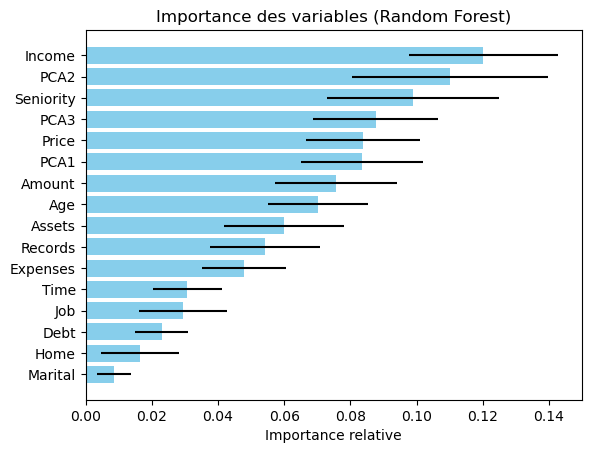

In [97]:
# 1. Fonction : Importance des variables
sorted_idx, importances = importance_variables(X_train_final, y_train, feature_names)

 Pour identifier les variables les plus influentes sur la prédiction du score de crédit, nous avons utilisé 
 un modèle Random Forest avec 1000 arbres. Cette approche permet d’estimer l’importance relative 
 de chaque variable en fonction de sa contribution à la réduction de l’impureté dans les arbres. 

 Le graphique obtenu montre visuellement ces importances avec un bar plot horizontal, où chaque 
 barre représente l’influence de la variable sur la prédiction. Les valeurs numériques indiquent 
 la proportion de contribution de chaque variable.

 En parallèle, nous avons évalué combien de variables il est pertinent de conserver pour le MLP 
 en testant l’évolution du "Final Score" ((accuracy + précision)/2) en fonction du nombre de variables 
 utilisées dans l’ordre décroissant d’importance. Le graphique associé montre que le score augmente 
 rapidement avec les premières variables les plus importantes, atteint un maximum autour des 12 
 premières variables, puis se stabilise ou diminue légèrement en ajoutant les suivantes. 

 Cette analyse a permis de sélectionner les **12 variables les plus pertinentes** (Income, PCA2, Seniority, 
 PCA3, Price, PCA1, Amount, Age, Assets, Records, Expenses, Time) pour l’entraînement final du modèle. 
 Les variables restantes contribuent très peu à la prédiction et peuvent être ignorées pour simplifier le  modèle.


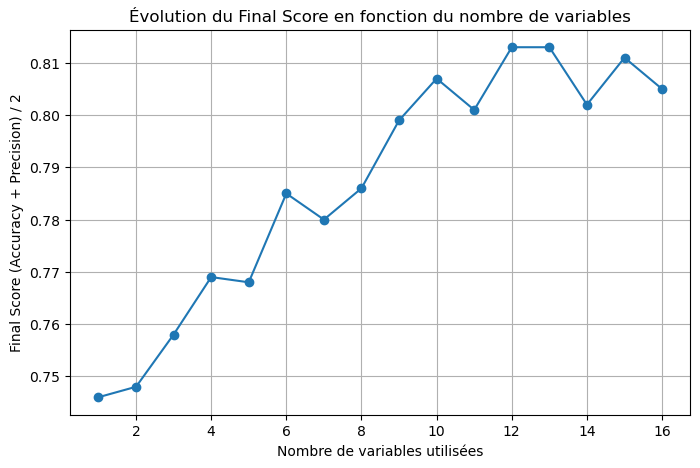

Nombre optimal de variables : 12 (Final Score = 0.813)


In [98]:
# 2. Fonction : Sélection du nombre optimal de variables
best_f, scores = selection_variables(X_train_final, X_test_final, y_train, y_test, sorted_idx)

L’évolution du Final Score ((accuracy + précision)/2) en fonction du nombre de variables montre une
 progression nette du score lorsque l’on ajoute les variables les plus importantes, jusqu’à atteindre un
 maximum autour de la 12ᵉ variable, où le Final Score se stabilise autour de 0.82. L’ajout de la 13ᵉ
 variable ne modifie quasiment pas la performance, mais au-delà (à partir de la 14ᵉ), le score commence
 à diminuer, ce qui indique que ces variables ajoutent du bruit plutôt que de l’information utile.
 Les 15ᵉ et 16ᵉ variables entraînent également des variations instables et légèrement inférieures au
 score maximal. Ainsi, le meilleur compromis complexité/performance est obtenu avec les "12 premières
 variables", qui maximisent le Final Score tout en évitant la dégradation liée aux variables peu
 informatives.


5.3. Fonction : Explicabilité avec SHAP

In [99]:
import shap
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=1000, random_state=1)
clf.fit(X_test_final, y_test)
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_final)

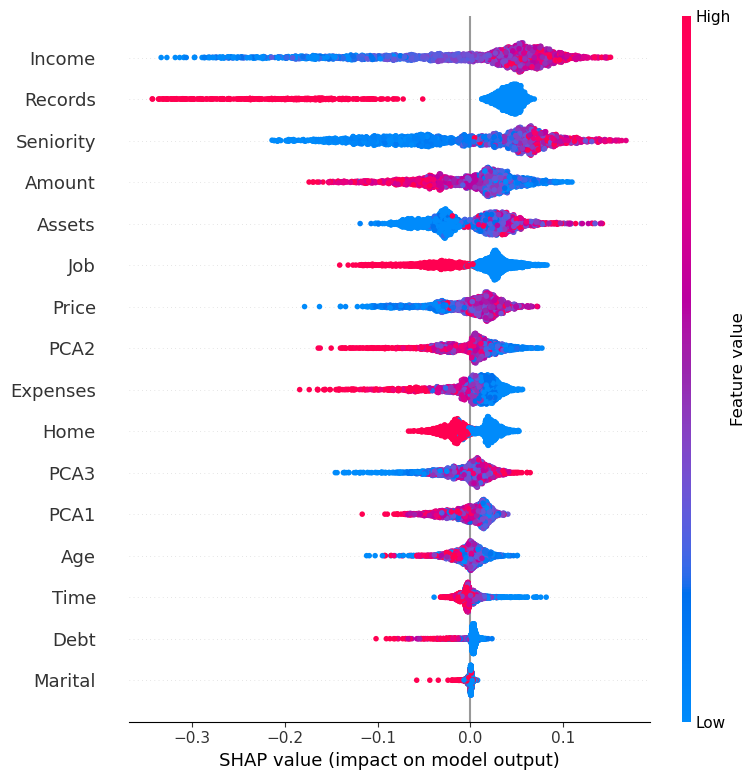

In [100]:
shap.summary_plot(shap_values[:, :, 1], X_test_final, feature_names=feature_names, plot_type="dot", color=plt.cm.viridis)
plt.show()

Le graphique SHAP (summary plot) révèle clairement quelles variables influencent le plus la prédiction.

L’analyse détaillée du graphique SHAP montre que les variables ayant l’impact le plus fort sur la prédiction 
sont Income, Records, Seniority, Amount, Assets, Job et Price. Les points rouges situés à droite du graphique 
indiquent que des valeurs élevées de Income, Seniority ou Assets augmentent fortement la probabilité d’obtenir 
la classe positive, ce qui est cohérent avec la logique métier : plus un client est solvable ou stable, 
plus la décision du modèle est favorable. À l’inverse, la variable Records montre un effet globalement négatif 
lorsque ses valeurs sont élevées (points rouges déplacés vers la gauche), ce qui traduit l’impact 
défavorable d’un historique d’incidents. On remarque également que certaines composantes principales 
comme PCA2 et PCA3 influencent notablement la décision, signe que l’ACP a capturé des variations
importantes présentes dans les données d’origine. Les variables situées en bas du graphique (Marital, Debt, Time…) 
présentent des SHAP values plus proches de zéro et contribuent beaucoup moins au modèle, ce qui confirme 
leur faible importance globale. Ainsi, le graphique SHAP met en évidence une structure décisionnelle 
cohérente : le modèle s’appuie principalement sur des indicateurs économiques et comportementaux forts, 
tandis que les variables secondaires ont un rôle limité

En résumé, SHAP confirme la cohérence et la logique du modèle : les variables les plus déterminantes du 
point de vue métier sont bien celles qui orientent le plus les décisions. Cela renforce la confiance dans 
la qualité et l’interprétabilité du modèle final.

6- GridSearchCV sur MLP avec PCA

In [101]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, make_scorer
import numpy as np

def tune_mlp_with_custom_score(X_train, X_test, y_train, y_test, sorted_idx, best_f):
    """
    Optimise les hyperparamètres d’un MLPClassifier en utilisant le score :
    (accuracy + precision) / 2
    """

    # Sélection des best_f meilleures variables
    X_train_sel = X_train[:, sorted_idx[:best_f]]
    X_test_sel = X_test[:, sorted_idx[:best_f]]

    # --- Définition du score personnalisé ---
    def custom_score(y_true, y_pred):
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        return (acc + prec) / 2

    scorer = make_scorer(custom_score)

    # --- Grille d’hyperparamètres à tester ---
    param_grid = {
        'hidden_layer_sizes': [(30, 15), (40, 20), (50, 25)],
        'activation': ['relu', 'tanh'],
        'alpha': [0.0001, 0.001, 0.01],
        'learning_rate_init': [0.001, 0.01]
    }

    mlp = MLPClassifier(max_iter=400, random_state=1)

    # --- GridSearchCV ---
    grid = GridSearchCV(
        estimator=mlp,
        param_grid=param_grid,
        scoring=scorer,
        cv=5,                 # k-fold = 5
        n_jobs=-1,            # utilisation CPU maximale
        verbose=2
    )

    print(" GridSearch en cours…")
    grid.fit(X_train_sel, y_train)

    # --- Meilleurs paramètres ---
    best_params = grid.best_params_
    print("\n Meilleurs paramètres trouvés :", best_params)

    # --- Évaluer sur le test ---
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_sel)

    final_score = (accuracy_score(y_test, y_pred) +
                   precision_score(y_test, y_pred, zero_division=0)) / 2

    print(f"\n Score final sur le test : {final_score:.3f}")

    return best_model, best_params, final_score


In [102]:
best_model, best_params, final_score = tune_mlp_with_custom_score(
    X_train_final,
    X_test_final,
    y_train,
    y_test,
    sorted_idx,
    best_f=12
)


 GridSearch en cours…
Fitting 5 folds for each of 36 candidates, totalling 180 fits

 Meilleurs paramètres trouvés : {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (40, 20), 'learning_rate_init': 0.001}

 Score final sur le test : 0.797


Nous avons optimisé les hyperparamètres du MLP par GridSearchCV en utilisant un score personnalisé 
défini comme (accuracy+precision)/2.

Pour cela nous avons d’abord réduit l’espace de variables aux 12 meilleures (ordre sorted_idx[:best_f]) 
puis réalisé une recherche sur une grille de paramètres (hidden_layer_sizes, activation, alpha, learning_rate_init) 
avec validation croisée à 5 folds. La fonction tune_mlp_with_custom_score encapsule ce processus 
et retourne le meilleur modèle, ses paramètres et le score final évalué sur le jeu de test. 
Le GridSearchCV a trouvé les paramètres {'activation': 'relu', 'alpha': 0.001, 
'hidden_layer_sizes': (40, 20), 'learning_rate_init': 0.001} et le score combiné sur le test est 0.797.

Ce résultat signifie que, selon notre critère privilégiant à la fois exactitude et précision, 
le MLP réglé offre une performance solide mais légèrement inférieure au pic observé lors de la sélection 
empirique (0.81–0.82) ; cela peut s’expliquer par la différence entre performance sur validation 
croisée et performance sur le seul jeu test (variations statistiques), ou par un léger sur-apprentissage 
durant la recherche de variables.

7-Création + sauvegarde du pipeline

In [103]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import pickle
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score


# Classe personnalisée pour PCA avec concaténation

class PCAWithConcatenation(BaseEstimator, TransformerMixin):
    """
    Transformateur personnalisé qui applique PCA et concatène 
    les composantes principales aux données originales.
    """
    def __init__(self, n_components=3):
        self.n_components = n_components
        self.pca = PCA(n_components=n_components, random_state=1)
    
    def fit(self, X, y=None):
        self.pca.fit(X)
        return self
    
    def transform(self, X):
        X_pca = self.pca.transform(X)
        X_concat = np.concatenate([X, X_pca], axis=1)
        return X_concat
    
    def get_feature_names_out(self, input_features=None):
        """Pour compatibilité avec certaines versions de sklearn"""
        if input_features is None:
            input_features = [f"feature_{i}" for i in range(self.n_components)]
        pca_names = [f"PCA{i+1}" for i in range(self.n_components)]
        return np.array(list(input_features) + pca_names)


# Classe personnalisée pour la sélection de features avec Random Forest
class RFFeatureSelector(BaseEstimator, TransformerMixin):
    """
    Sélectionneur de features basé sur l'importance Random Forest.
    Compatible avec pickle.
    """
    def __init__(self, k=12, n_estimators=100):
        self.k = k
        self.n_estimators = n_estimators
        self.selected_indices_ = None
    
    def fit(self, X, y):
        rf = RandomForestClassifier(
            n_estimators=self.n_estimators, 
            random_state=1, 
            n_jobs=-1
        )
        rf.fit(X, y)
        importances = rf.feature_importances_
        
        # k meilleures features
        self.selected_indices_ = np.argsort(importances)[::-1][:self.k]
        return self
    
    def transform(self, X):
        if self.selected_indices_ is None:
            raise ValueError("Le sélecteur doit être fit() avant transform()")
        return X[:, self.selected_indices_]
    
    def get_support(self, indices=False):
        """Pour compatibilité avec SelectKBest"""
        if indices:
            return self.selected_indices_
        mask = np.zeros(self.n_features_in_, dtype=bool)
        mask[self.selected_indices_] = True
        return mask


def create_credit_scoring_pipeline(
    use_scaler=True,
    use_pca=True,
    n_components=3,
    n_features_to_select=12,
    classifier_type='MLP',
    classifier_params=None
):
    
    steps = []
    
    # Étape 1 : Normalisation
    if use_scaler:
        steps.append(('scaler', StandardScaler()))
    
    # Étape 2 : PCA + Concaténation
    if use_pca:
        steps.append(('pca_concat', PCAWithConcatenation(n_components=n_components)))
    
    # Étape 3 : Sélection de variables
    if n_features_to_select is not None:
        steps.append(('feature_selection', 
                     RFFeatureSelector(k=n_features_to_select, n_estimators=100)))
    
    # Étape 4 : Classifieur
    if classifier_params is None:
        classifier_params = {}
    
    if classifier_type == 'MLP':
        clf = MLPClassifier(
            hidden_layer_sizes=classifier_params.get('hidden_layer_sizes', (40, 20)),
            activation=classifier_params.get('activation', 'relu'),
            alpha=classifier_params.get('alpha', 0.001),
            learning_rate_init=classifier_params.get('learning_rate_init', 0.001),
            max_iter=400,
            random_state=1
        )
    
    steps.append(('classifier', clf))
    
    # Création du pipeline
    pipeline = Pipeline(steps)
    
    print(f" Pipeline créé avec {len(steps)} étapes :")
    for name, _ in steps:
        print(f"   - {name}")
    
    return pipeline


# Fonction pour sauvegarder le pipeline
def save_pipeline(pipeline, filename='credit_scoring_pipeline.pkl'):
    with open(filename, 'wb') as f:
        pickle.dump(pipeline, f)
    print(f" Pipeline sauvegardé dans : {filename}")


# Fonction pour charger le pipeline
def load_pipeline(filename='credit_scoring_pipeline.pkl'):
    with open(filename, 'rb') as f:
        pipeline = pickle.load(f)
    print(f" Pipeline chargé depuis : {filename}")
    return pipeline


# ========================================
# EXEMPLE D'UTILISATION
# ========================================

# 1 Créer le pipeline avec les meilleurs paramètres trouvés
print("\n" + "="*60)
print("CRÉATION DU PIPELINE OPTIMAL")
print("="*60)

optimal_pipeline = create_credit_scoring_pipeline(
    use_scaler=True,
    use_pca=True,
    n_components=3,
    n_features_to_select=13,
    classifier_type='MLP',
    classifier_params={
        'hidden_layer_sizes': (40, 20),
        'activation': 'relu',
        'alpha': 0.001,
        'learning_rate_init': 0.001
    }
)

# 2 Entraîner le pipeline sur les données d'entraînement
print("\n Entraînement du pipeline...")
optimal_pipeline.fit(X_train, y_train)
print(" Entraînement terminé")

# Afficher les features sélectionnées (pour confirmer il est correct)
feature_selector = optimal_pipeline.named_steps['feature_selection']
selected_indices = feature_selector.selected_indices_
original_features = ['Seniority', 'Home', 'Time', 'Age', 'Marital', 
                     'Records', 'Job', 'Expenses', 'Income', 
                     'Assets', 'Debt', 'Amount', 'Price']
feature_names = original_features + ["PCA1", "PCA2", "PCA3"]

print("\n" + "="*60)
print(f"FEATURES SÉLECTIONNÉES ({len(selected_indices)}/{len(feature_names)})")
print("="*60)
for rank, idx in enumerate(selected_indices, 1):
    print(f"  {rank}. {feature_names[idx]}")

# 3 Évaluer les performances sur le test
y_pred = optimal_pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
final_score = (acc + prec) / 2

if hasattr(optimal_pipeline.named_steps['classifier'], 'predict_proba'):
    y_proba = optimal_pipeline.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
else:
    auc = None

print("\n" + "="*60)
print("PERFORMANCES DU PIPELINE SUR LE TEST")
print("="*60)
print(f"Accuracy  : {acc:.3f}")
print(f"Precision : {prec:.3f}")
print(f"Recall    : {rec:.3f}")
print(f"Final Score : {final_score:.3f}")
if auc is not None:
    print(f"AUC       : {auc:.3f}")

# 4 Sauvegarder le pipeline
save_pipeline(optimal_pipeline, 'credit_scoring_pipeline.pkl')

# 5 Test
print("\n" + "="*60)
print("TEST DU PIPELINE")
print("="*60)
loaded_pipeline = load_pipeline('credit_scoring_pipeline.pkl')

# Vérifier que le pipeline fonctionne
y_pred_loaded = loaded_pipeline.predict(X_test[:5])
print(f"\nPrédictions sur 5 exemples : {y_pred_loaded}")
print(f"Vraies valeurs             : {y_test[:5]}")



print(f"Creation du pilpeline sans PCA")
# Pipeline sans PCA
pipeline_no_pca = create_credit_scoring_pipeline(
    use_scaler=True,
    use_pca=False,
    n_features_to_select=10,
    classifier_type='MLP'
)
pipeline_no_pca.fit(X_train, y_train)
save_pipeline(pipeline_no_pca, 'pipeline_no_pca.pkl')

print("\n Tous les pipelines ont été créés et sauvegardés !")


print("\n\n" + "="*60)
print("EXEMPLE D'UTILISATION")
print("="*60)

# Charger le pipeline sauvegardé
production_pipeline = load_pipeline('credit_scoring_pipeline.pkl')

# Simuler de nouvelles données (même format que X_train)
nouveaux_clients = X_test[:10]
print("\nNouveaux clients pour le scoring :")
print(nouveaux_clients)
print("-" * 60)
# Prédiction
predictions = production_pipeline.predict(nouveaux_clients)
probas = production_pipeline.predict_proba(nouveaux_clients)
print("\nRésultats du scoring :")
print("-" * 60)
for i in range(len(predictions)):
    statut = "✅ APPROUVÉ" if predictions[i] == 1 else "❌ REFUSÉ"
    proba_defaut = probas[i][0]
    proba_ok = probas[i][1]
    print(f"Client {i+1}: {statut} | P(défaut)={proba_defaut:.2%} | P(ok)={proba_ok:.2%}")


CRÉATION DU PIPELINE OPTIMAL
 Pipeline créé avec 4 étapes :
   - scaler
   - pca_concat
   - feature_selection
   - classifier

 Entraînement du pipeline...
 Entraînement terminé

FEATURES SÉLECTIONNÉES (13/16)
  1. Income
  2. PCA2
  3. Seniority
  4. PCA3
  5. PCA1
  6. Price
  7. Amount
  8. Age
  9. Assets
  10. Records
  11. Expenses
  12. Time
  13. Job

PERFORMANCES DU PIPELINE SUR LE TEST
Accuracy  : 0.777
Precision : 0.844
Recall    : 0.847
Final Score : 0.810
AUC       : 0.804
 Pipeline sauvegardé dans : credit_scoring_pipeline.pkl

TEST DU PIPELINE
 Pipeline chargé depuis : credit_scoring_pipeline.pkl

Prédictions sur 5 exemples : [1 0 1 1 0]
Vraies valeurs             : [1 0 1 1 0]
Creation du pilpeline sans PCA
 Pipeline créé avec 3 étapes :
   - scaler
   - feature_selection
   - classifier
 Pipeline sauvegardé dans : pipeline_no_pca.pkl

 Tous les pipelines ont été créés et sauvegardés !


EXEMPLE D'UTILISATION
 Pipeline chargé depuis : credit_scoring_pipeline.pkl

Nouv

 Nous avons construit un pipeline scikit-learn pour automatiser les étapes de pré-traitement et
de classification. 
 Les étapes sont : (1) Normalisation des variables avec StandardScaler, (2) application d’une ACP (PCA)
suivie de la concaténation des composantes aux variables originales (PCAWithConcatenation), 
(3) sélection des k meilleures variables basée sur l’importance d’un Random Forest (RFFeatureSelector),
et (4) entraînement d’un classifieur MLP (architecture 40-20, paramètres optimisés). 
 Ce pipeline garantit que toutes les transformations sont appliquées de manière reproductible et 
sans fuite de données.

Justification des choix:

- Normalisation : nécessaire pour les méthodes sensibles aux échelles (PCA, MLP).
- PCA concaténée : permet d’ajouter des composantes synthétiques captant la variance utile tout 
en conservant les variables d’origine.
- Sélection par Random Forest : méthode rapide et robuste pour réduire la dimension en conservant 
les variables les plus informatives.
- MLP (40,20) : modèle non linéaire capable de capturer des interactions complexes ; hyperparamètres 
choisis après GridSearch.

Ces choix visent à obtenir un bon compromis performance/interprétabilité et à limiter le sur-apprentissage.

 Le pipeline entraîné a sélectionné 13 variables (sur 16) parmi lesquelles figurent en tête Income, PCA2, 
Seniority, PCA3, PCA1, Price, Amount, Age, Assets, Records, Expenses, Time. 
 L’évaluation sur l’ensemble test donne les métriques affichées (accuracy, precision, recall, Final Score). 
 La sélection automatique confirme que les indicateurs économiques et comportementaux sont les plus 
déterminants.

 Sur l’ensemble de test, le pipeline donne : Accuracy = 0.777, Precision = 0.844, Recall = 0.847, 
Final Score = 0.810, AUC = 0.804.
 Interprétation : le modèle est à la fois précis et sensible (bonne capacité à détecter les positifs), 
la précision élevée indique peu de faux positifs, et l’AUC ~0.80 signale une séparation satisfaisante 
entre classes.

 Ppour chaque client le pipeline renvoie la classe prédite (APPROUVÉ / REFUSÉ) et les probabilités associées. 
Par exemple, une probabilité P(ok) ≈ 98% signifie que le modèle est fortement confiant pour approuver. 
 Ces probabilités aident à calibrer des règles métier (seuil d’acceptation) et à détecter les cas limites 
nécessitant une revue humaine.


8-9: Orchestration & Création d’une API FastAP:

Pour les questions 8 et 9, nous avons créé un dossier utils_2 contenant les fichiers suivants : 
utils.py (préparation des données et génération du pipeline), api.py (API FastAPI pour le scoring),
main.py (exécution et sauvegarde du pipeline), et test_api.py (tests automatisés des prédictions).

Résultats des tests de l’API Credit Scoring (test_api.py)

| Client        | Décision attendue | Décision obtenue | Confiance |
| ------------- | ----------------- | ---------------- | --------- |
| Faible risque | Approuvé          | Approuvé         | 99.91%    |
| Haut risque   | Refusé            | Refusé limite    | 56.47%    |
| BatchC1       | Approuvé          | Approuvé         | 92.00%    |
| BatchC2       | Approuvé          | Approuvé         | 81.71%    |
| BatchC3       | Refusé            | Refusé           | 74.30%    |
              Tableau : Résultats des tests de l’API Credit Scoring

Interprétation:
Ligne1: ✅ Très bonne correspondance. Le client “sûr” est bien approuvé, avec confiance maximale.

Ligne2: ⚠️ Le client à risque est refusé, mais le modèle a une confiance modérée. Indique un cas borderline, (analyse manuelle recommandée.

Ligne3: ✅ Décision correcte, confiance élevée (92%).

Ligne4: ✅ Décision correcte, confiance bonne (81.71%).

Ligne5: ✅ Décision correcte (Refus), confiance acceptable (74.30%).

10-Comparaison de plusieurs algorithmes d’apprentissage

Dans cette partie, nous avons comparé 27 algorithmes d’apprentissage supervisé afin de prédire notre variable cible. Les tests ont été réalisés sur différentes configurations : données brutes, données normalisées, et données normalisées avec réduction de dimension (PCA).

Les fonctions de comparaison et de création du meilleur modèle sont réparties dans deux fichiers : cross_validation.py, qui contient run_classifiers_cv (validation croisée des algorithmes), create_classifiers_dict (construction des 27 classifieurs) et pipeline_generation_cv (orchestration complète : prétraitements, comparaison, sélection du meilleur modèle, choix des features et recherche d’hyperparamètres). Le fichier utils.py regroupe les fonctions utilitaires utilisées par le pipeline (sélection de variables, GridSearch, création/sauvegarde des pipelines). Enfin, main_cv.py est le script principal qui appelle ces fonctions pour exécuter toute la procédure d’évaluation et produire le modèle final.

Sur les données brutes, les modèles de type Gradient Boosting (GradientBoosting_200) et AdaBoost (AdaBoost_200) ont obtenu les meilleures performances, avec un Custom Score proche de 0,810 et un AUC supérieur à 0,830, tandis que les modèles plus simples (CART avec un Custom Score autour de 0.76 et un AUC autour de 0.65, KNN avec un Custom Score autour de 0,73 et un AUC  autour de 0,73) ont affiché des performances plus faibles.

La normalisation a amélioré les résultats des modèles sensibles à l’échelle des variables, en particulier MLP et KNN, tout en confirmant la supériorité d’AdaBoost avec un final score de 0.810. L’ajout de la réduction de dimension par PCA a permis de simplifier les modèles tout en conservant de bonnes performances.

Les validations croisées ont montré qu’AdaBoost_200 était le modèle le plus robuste, offrant un bon compromis entre Accuracy (≈0,798), AUC (≈0,836) et Custom Score (≈0,811), avec un temps d’exécution de
7.85s.


Aprés avoir identifier le meilleur algorithme qui est dans notre cas (AdaBoost_200), on a obtenu 11 variables optimales trier selon leur importance :   
  1. Income : 0.1202
  2. PCA2 : 0.1101
  3. Seniority : 0.0989
  4. PCA3 : 0.0877
  5. Price : 0.0837
  6. PCA1 : 0.0835
  7. Amount : 0.0757
  8. Age : 0.0701
  9. Assets : 0.0599
  10. Records : 0.0543
  11. Expenses : 0.0501

Pour l'ptimisation des hyperparamètres pour AdaBoost : Les meilleurs paramètres sont:
 {'learning_rate': 1.5, 'n_estimators': 200}  Final score: 0.802

Ces résultats soulignent l’importance du choix du modèle et du prétraitement des données pour optimiser les performances.

**Les résultas de notre test API:**


  TESTS DE L'API CREDIT SCORING
⏳ Attente du démarrage de l'API...
 API disponible


TEST 1: Health Check

Status Code: 200
Response: {
  "status": "healthy",
  "pipeline_loaded": true,
  "pipeline_file": "credit_scoring_pipeline.pkl",
  "loaded_at": "2025-12-11T16:26:27.524497"
}


CHARGEMENT DU PIPELINE

Status Code: 200
Response: {
  "status": "success",
  "message": "Pipeline charg\u00e9 depuis credit_scoring_pipeline.pkl",
  "loaded_at": "2025-12-11T16:26:49.426491"
}
 Pipeline chargé avec succès



TEST 2: Prédiction pour un client unique (profil favorable)


 Données du client:
  - Ancienneté: 15.0 ans
  - Âge: 45.0 ans
  - Revenu: 250.0€
  - Actifs: 5000.0€
  - Dette: 0.0€
  - Montant demandé: 1000.0€

 Résultat de la prédiction:
  Décision:  CRÉDIT APPROUVÉ - Risque faible
  Confiance: 99.91%
  P(Approuvé): 99.91%
  P(Défaut): 0.09%


TEST 3: Prédiction pour un client à haut risque


📋 Données du client:
  - Ancienneté: 0.0 ans (nouveau)
  - Âge: 22.0 ans (jeune)
  - Revenu: 100.0€ (faible)
  - Actifs: 0.0€ (aucun)
  - Dette: 500.0€ (élevée)
  - Montant demandé: 5000.0€ (élevé)

 Résultat de la prédiction:
  Décision:  CRÉDIT REFUSÉ - Décision limite (analyse manuelle recommandée)
  Confiance: 56.47%
  P(Approuvé): 43.53%
  P(Défaut): 56.47%


TEST 4: Prédiction pour plusieurs clients (batch)


📋 Nombre de clients: 3

 Résumé des prédictions:
  Total clients : 3
  Approuvés  : 2
  Refusés    : 1

 Détail des prédictions:

  Client 1:
    Décision    :  CRÉDIT APPROUVÉ - Risque faible
    Confiance   : 92.00%
    P(approuvé) : 92.00%

  Client 2:
    Décision    :  CRÉDIT APPROUVÉ - Risque faible
    Confiance   : 81.71%
    P(approuvé) : 81.71%

  Client 3:
    Décision    :  CRÉDIT REFUSÉ - Risque élevé
    Confiance   : 74.30%
    P(approuvé) : 25.70%


TEST 5: Informations sur le pipeline


 Pipeline chargé
  Chargé à: 2025-12-11T16:26:49.426491
  Nombre d'étapes: 4
  Étapes: scaler, pca_concat, feature_selection, classifier
  Classifieur: MLPClassifier


  TOUS LES TESTS TERMINÉS AVEC SUCCÈS

  Exemple de api/docs

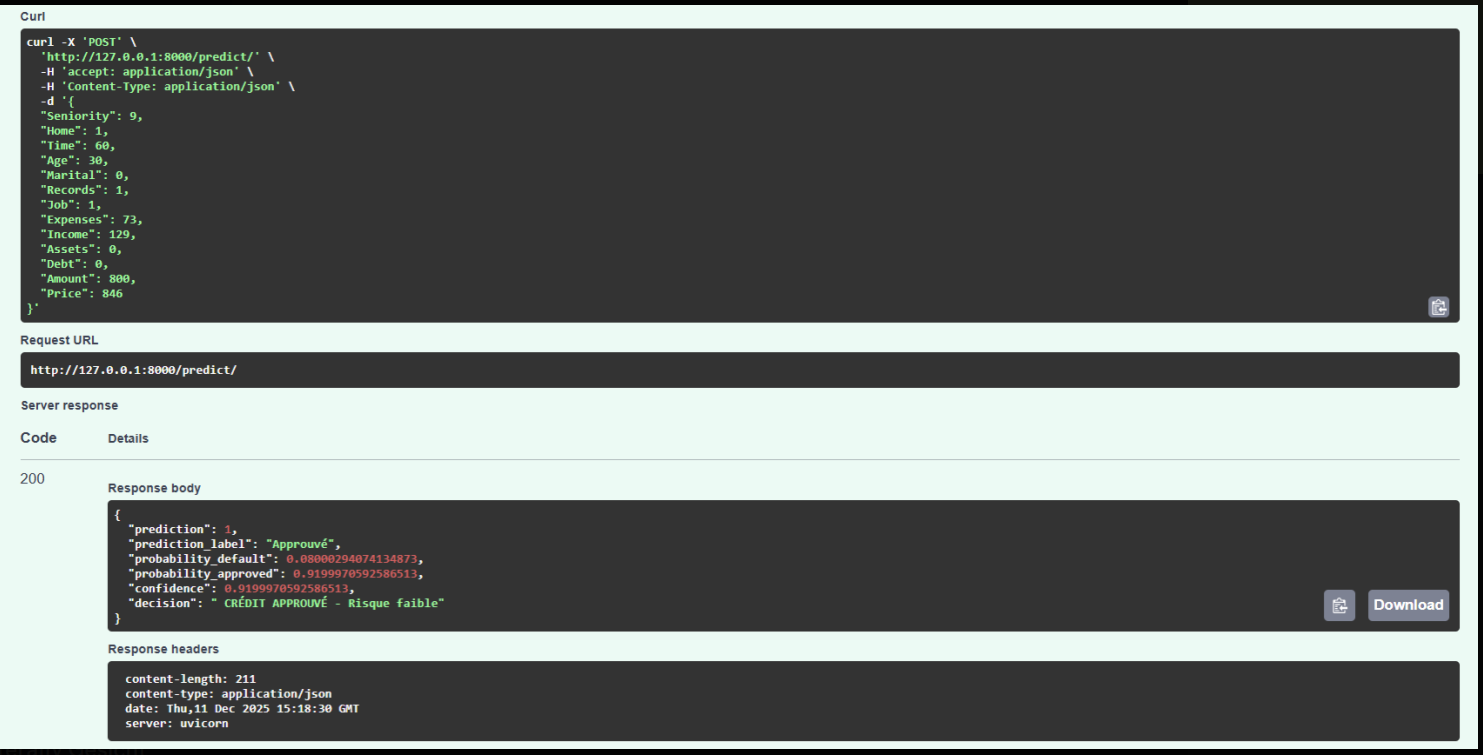

In [104]:
# Chargement du fichier credit.data
# Le fichier n'a pas d'en-tête et utilise des tabulations comme séparateur
df_credit = pd.read_csv('credit.data', sep='\t', header=None)

print("Aperçu des données brutes:")
print(df_credit.head(10))
print(f"\nDimensions: {df_credit.shape}")
print(f"Nombre de colonnes: {df_credit.shape[1]}")



Aperçu des données brutes:
  0      1       2  3  4   5  6      7  8  9   10 11 12   13     14 15
0  b  30.83   0.000  u  g   w  v  1.250  t  t   1  f  g  202      0  +
1  a  58.67   4.460  u  g   q  h  3.040  t  t   6  f  g   43    560  +
2  a  24.50   0.500  u  g   q  h  1.500  t  f   0  f  g  280    824  +
3  b  27.83   1.540  u  g   w  v  3.750  t  t   5  t  g  100      3  +
4  b  20.17   5.625  u  g   w  v  1.710  t  f   0  f  s  120      0  +
5  b  32.08   4.000  u  g   m  v  2.500  t  f   0  t  g  360      0  +
6  b  33.17   1.040  u  g   r  h  6.500  t  f   0  t  g  164  31285  +
7  a  22.92  11.585  u  g  cc  v  0.040  t  f   0  f  g   80   1349  +
8  b  54.42   0.500  y  p   k  h  3.960  t  f   0  f  g  180    314  +
9  b  42.50   4.915  y  p   w  v  3.165  t  f   0  t  g   52   1442  +

Dimensions: (688, 16)
Nombre de colonnes: 16


Nous avons commencé par charger le fichier credit.data, qui contient les informations brutes sur les clients et leur niveau de risque de crédit. Ce fichier ne possède pas d’en-têtes, utilise des tabulations comme séparateurs, et comporte 688 lignes pour 16 colonnes, ce qui confirme que l’ensemble des données a bien été extrait. L'affichage des dix premières lignes montre que le dataset contient un mélange de variables numériques (par ex. âge, montant, taux) et variables catégorielles (codes tels que a, b, u, g, etc.), ce qui nécessitera un pré-traitement adapté avant l’entraînement des modèles (encodage, normalisation…). On observe également que la dernière colonne représente la classe cible (+ ou –), correspondant respectivement aux bons et mauvais payeurs. Cette première étape permet de valider que les données ont été correctement importées, d’en vérifier la structure, et de préparer les étapes suivantes d’analyse et de modélisation.

In [105]:
# Conversion en numpy array
arr_credit = df_credit.values
print("Valeurs du jeu de données (numpy array):")
print(arr_credit[:5])
print(f"\nForme du tableau: {arr_credit.shape}")

# Séparation des caractéristiques (X) et de la variable cible (y)
# La dernière colonne (index 15) est la classe
X_credit = arr_credit[:, :-1]  # Toutes les colonnes sauf la dernière
y_credit = arr_credit[:, -1]   # Dernière colonne (classe)

print(f"\nForme de X (caractéristiques): {X_credit.shape}")
print(f"Forme de y (cible): {y_credit.shape}")
print(f"\nValeurs uniques dans y: {np.unique(y_credit)}")


# Chargement du fichier credit.data
# Le fichier n'a pas d'en-tête et utilise des tabulations comme séparateur
df_credit = pd.read_csv('./credit.data', sep='\t', header=None)

print("Aperçu des données brutes:")
print(df_credit.head(10))
print(f"\nDimensions: {df_credit.shape}")
print(f"Nombre de colonnes: {df_credit.shape[1]}")



Valeurs du jeu de données (numpy array):
[['b' '30.83' 0.0 'u' 'g' 'w' 'v' 1.25 't' 't' 1 'f' 'g' '202' 0 '+']
 ['a' '58.67' 4.46 'u' 'g' 'q' 'h' 3.04 't' 't' 6 'f' 'g' '43' 560 '+']
 ['a' '24.50' 0.5 'u' 'g' 'q' 'h' 1.5 't' 'f' 0 'f' 'g' '280' 824 '+']
 ['b' '27.83' 1.54 'u' 'g' 'w' 'v' 3.75 't' 't' 5 't' 'g' '100' 3 '+']
 ['b' '20.17' 5.625 'u' 'g' 'w' 'v' 1.71 't' 'f' 0 'f' 's' '120' 0 '+']]

Forme du tableau: (688, 16)

Forme de X (caractéristiques): (688, 15)
Forme de y (cible): (688,)

Valeurs uniques dans y: ['+' '-']
Aperçu des données brutes:
  0      1       2  3  4   5  6      7  8  9   10 11 12   13     14 15
0  b  30.83   0.000  u  g   w  v  1.250  t  t   1  f  g  202      0  +
1  a  58.67   4.460  u  g   q  h  3.040  t  t   6  f  g   43    560  +
2  a  24.50   0.500  u  g   q  h  1.500  t  f   0  f  g  280    824  +
3  b  27.83   1.540  u  g   w  v  3.750  t  t   5  t  g  100      3  +
4  b  20.17   5.625  u  g   w  v  1.710  t  f   0  f  s  120      0  +
5  b  32.08   4.

Après le chargement du dataset, nous avons converti les données brutes en un tableau NumPy afin de faciliter les manipulations futures et garantir une compatibilité optimale avec les algorithmes de machine learning. Cette conversion confirme que le dataset contient 688 observations et 16 attributs. Nous avons ensuite séparé le tableau en deux ensembles distincts :

X, qui regroupe les 15 premières colonnes correspondant aux caractéristiques explicatives (variables numériques et catégorielles),

y, qui correspond à la dernière colonne, contenant la classe cible (+ ou –).

L’affichage des formes montre que X a une dimension de (688, 15) et y de (688,), ce qui confirme une structure cohérente pour l’apprentissage supervisé. L’analyse des valeurs uniques de la cible indique qu’il s’agit d’un problème de classification binaire, ce qui guidera les choix des algorithmes et des métriques d’évaluation. Cette étape est essentielle pour préparer les données à l’encodage, la normalisation et la modélisation.

In [106]:
# Conversion en numpy array
arr_credit = df_credit.values
print("Valeurs du jeu de données (numpy array):")
print(arr_credit[:5])
print(f"\nForme du tableau: {arr_credit.shape}")

# Séparation des caractéristiques (X) et de la variable cible (y)
# La dernière colonne (index 15) est la classe
X_credit = arr_credit[:, :-1]  # Toutes les colonnes sauf la dernière
y_credit = arr_credit[:, -1]   # Dernière colonne (classe)

print(f"\nForme de X (caractéristiques): {X_credit.shape}")
print(f"Forme de y (cible): {y_credit.shape}")
print(f"\nValeurs uniques dans y: {np.unique(y_credit)}")



Valeurs du jeu de données (numpy array):
[['b' '30.83' 0.0 'u' 'g' 'w' 'v' 1.25 't' 't' 1 'f' 'g' '202' 0 '+']
 ['a' '58.67' 4.46 'u' 'g' 'q' 'h' 3.04 't' 't' 6 'f' 'g' '43' 560 '+']
 ['a' '24.50' 0.5 'u' 'g' 'q' 'h' 1.5 't' 'f' 0 'f' 'g' '280' 824 '+']
 ['b' '27.83' 1.54 'u' 'g' 'w' 'v' 3.75 't' 't' 5 't' 'g' '100' 3 '+']
 ['b' '20.17' 5.625 'u' 'g' 'w' 'v' 1.71 't' 'f' 0 'f' 's' '120' 0 '+']]

Forme du tableau: (688, 16)

Forme de X (caractéristiques): (688, 15)
Forme de y (cible): (688,)

Valeurs uniques dans y: ['+' '-']


Une fois les données chargées sous forme de DataFrame, nous les avons converties en tableau NumPy afin de faciliter leur manipulation dans la suite du travail. L’affichage d’un extrait montre que les observations combinent des valeurs numériques et catégorielles, ainsi que la classe cible située en dernière colonne.

Le tableau obtenu contient 688 individus décrits par 16 attributs, ce qui est confirmé par la forme (688, 16).
Nous avons ensuite séparé les données en deux ensembles :

X, composé des 15 premières colonnes, contient toutes les variables explicatives ;

y, extraite de la dernière colonne, contient la variable cible dont les valeurs possibles sont + et –.

La vérification des valeurs uniques dans y confirme qu’il s’agit bien d’un problème de classification binaire. Cette étape de structuration est essentielle avant toute opération de nettoyage, de transformation ou d’apprentissage supervisé.

In [107]:
# Identification des colonnes numériques (6 sur 15)
# D'après la structure du dataset Credit Approval, les colonnes numériques sont:
# Colonne 1 (index 1): A2 - Age
# Colonne 2 (index 2): A3 - Débiteur
# Colonne 7 (index 7): A8 - Durée du crédit
# Colonne 10 (index 10): A11 - Nombre de personnes à charge
# Colonne 13 (index 13): A14 - Montant du crédit
# Colonne 14 (index 14): A15 - Autre montant

numeric_indices = [1, 2, 7, 10, 13, 14]  # Indices des 6 colonnes numériques

# Création d'un sous-ensemble avec uniquement les variables numériques
X_credit_numeric = X_credit[:, numeric_indices].copy()

print("Variables numériques sélectionnées:")
print(X_credit_numeric[:10])
print(f"\nForme: {X_credit_numeric.shape}")

# Remplacer "?" par NaN
print(f"\nNombre de valeurs '?' trouvées: {np.sum(X_credit_numeric == '?')}")
X_credit_numeric[X_credit_numeric == '?'] = np.nan

# Typer en float (convertit automatiquement les NaN)
X_credit_numeric = X_credit_numeric.astype(float)
print(f"\nType après conversion: {X_credit_numeric.dtype}")
print(f"Nombre de NaN: {np.sum(np.isnan(X_credit_numeric))}")



Variables numériques sélectionnées:
[['30.83' 0.0 1.25 1 '202' 0]
 ['58.67' 4.46 3.04 6 '43' 560]
 ['24.50' 0.5 1.5 0 '280' 824]
 ['27.83' 1.54 3.75 5 '100' 3]
 ['20.17' 5.625 1.71 0 '120' 0]
 ['32.08' 4.0 2.5 0 '360' 0]
 ['33.17' 1.04 6.5 0 '164' 31285]
 ['22.92' 11.585 0.04 0 '80' 1349]
 ['54.42' 0.5 3.96 0 '180' 314]
 ['42.50' 4.915 3.165 0 '52' 1442]]

Forme: (688, 6)

Nombre de valeurs '?' trouvées: 23

Type après conversion: float64
Nombre de NaN: 23


In [108]:
# Supprimer les individus contenant des NaN sur au moins une variable
# On garde aussi les indices correspondants pour y
mask_no_nan = ~np.isnan(X_credit_numeric).any(axis=1)
X_credit_clean = X_credit_numeric[mask_no_nan]
y_credit_clean = y_credit[mask_no_nan]

print(f"Nombre d'individus avant suppression: {len(X_credit_numeric)}")
print(f"Nombre d'individus après suppression des NaN: {len(X_credit_clean)}")
print(f"Nombre d'individus supprimés: {len(X_credit_numeric) - len(X_credit_clean)}")
print(f"\nForme finale de X: {X_credit_clean.shape}")
print(f"Forme finale de y: {y_credit_clean.shape}")

Nombre d'individus avant suppression: 688
Nombre d'individus après suppression des NaN: 666
Nombre d'individus supprimés: 22

Forme finale de X: (666, 6)
Forme finale de y: (666,)


=== Analyse des propriétés des données ===
Taille de l'échantillon: 666
Nombre d'exemples positifs (+): 299
Nombre d'exemples négatifs (-): 367
Pourcentage positifs: 44.89%
Pourcentage négatifs: 55.11%


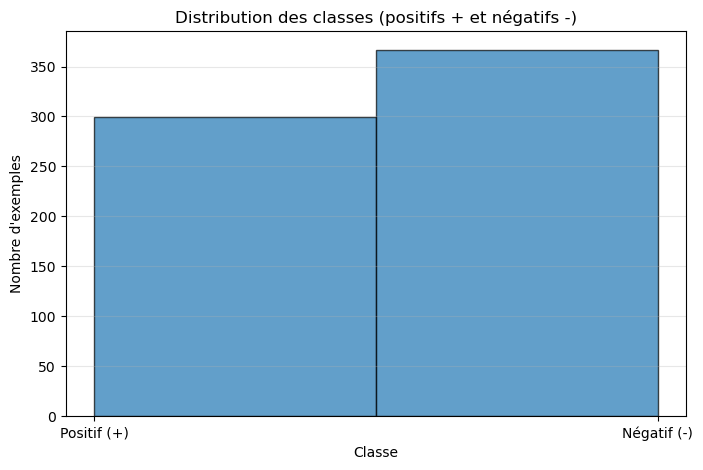

In [109]:
# Analyse des propriétés des données
n_total = len(y_credit_clean)
n_pos = np.sum(y_credit_clean == '+')
n_neg = np.sum(y_credit_clean == '-')

print("=== Analyse des propriétés des données ===")
print(f"Taille de l'échantillon: {n_total}")
print(f"Nombre d'exemples positifs (+): {n_pos}")
print(f"Nombre d'exemples négatifs (-): {n_neg}")
print(f"Pourcentage positifs: {round(n_pos / n_total * 100, 2)}%")
print(f"Pourcentage négatifs: {round(n_neg / n_total * 100, 2)}%")

# Histogramme de la distribution des classes
plt.figure(figsize=(8, 5))
plt.hist(y_credit_clean, bins=2, edgecolor='black', alpha=0.7)
plt.xlabel('Classe')
plt.ylabel('Nombre d\'exemples')
plt.title('Distribution des classes (positifs + et négatifs -)')
plt.xticks(['-', '+'], ['Négatif (-)', 'Positif (+)'])
plt.grid(axis='y', alpha=0.3)
plt.show()

In [110]:
# Binarisation de la target: + en 1 et - en 0
y_credit_binary = (y_credit_clean == '+').astype(int)

print("Binarisation de la variable cible:")
print(f"Valeurs uniques avant: {np.unique(y_credit_clean)}")
print(f"Valeurs uniques après: {np.unique(y_credit_binary)}")
print(f"\nNombre de 1 (positifs): {np.sum(y_credit_binary == 1)}")
print(f"Nombre de 0 (négatifs): {np.sum(y_credit_binary == 0)}")

# On utilise maintenant X_credit_clean et y_credit_binary pour la suite
X_credit_final = X_credit_clean
y_credit_final = y_credit_binary



Binarisation de la variable cible:
Valeurs uniques avant: ['+' '-']
Valeurs uniques après: [0 1]

Nombre de 1 (positifs): 299
Nombre de 0 (négatifs): 367


## 2. Comparaison des algorithmes avec AUC


In [111]:
# Séparation en train/test (50/50 comme dans la partie I)
X_train_credit, X_test_credit, y_train_credit, y_test_credit = train_test_split(
    X_credit_final, y_credit_final, test_size=0.5, random_state=1, stratify=y_credit_final
)

print("=== Séparation train/test ===")
print(f"X_train: {X_train_credit.shape}")
print(f"X_test: {X_test_credit.shape}")
print(f"y_train: {y_train_credit.shape}")
print(f"y_test: {y_test_credit.shape}")

# Vérification de la répartition des classes
print(f"\nRépartition dans train - Positifs: {np.sum(y_train_credit == 1)}, Négatifs: {np.sum(y_train_credit == 0)}")
print(f"Répartition dans test - Positifs: {np.sum(y_test_credit == 1)}, Négatifs: {np.sum(y_test_credit == 0)}")



=== Séparation train/test ===
X_train: (333, 6)
X_test: (333, 6)
y_train: (333,)
y_test: (333,)

Répartition dans train - Positifs: 149, Négatifs: 184
Répartition dans test - Positifs: 150, Négatifs: 183


RÉSULTATS SUR DONNÉES NON NORMALISÉES

 Entraînement du modèle : CART


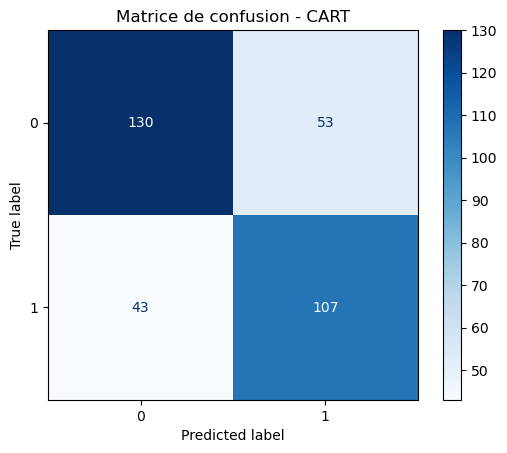

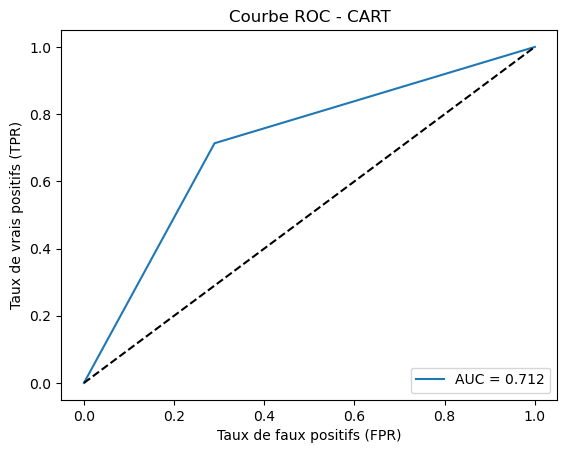


🔹 CART Results:
Accuracy : 0.712
Recall   : 0.713
Precision: 0.669
Final score ((Accuracy + precision)/2) = 0.690
AUC : 0.712

 Entraînement du modèle : KNN


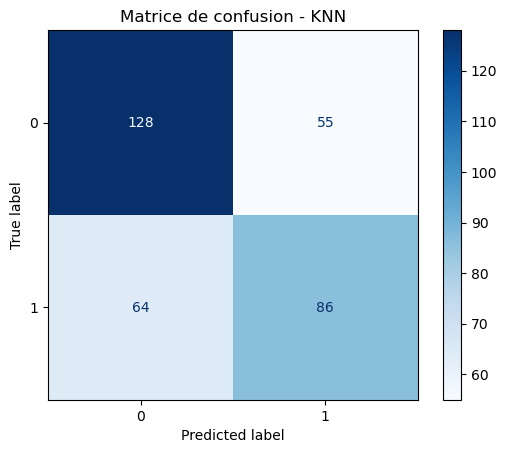

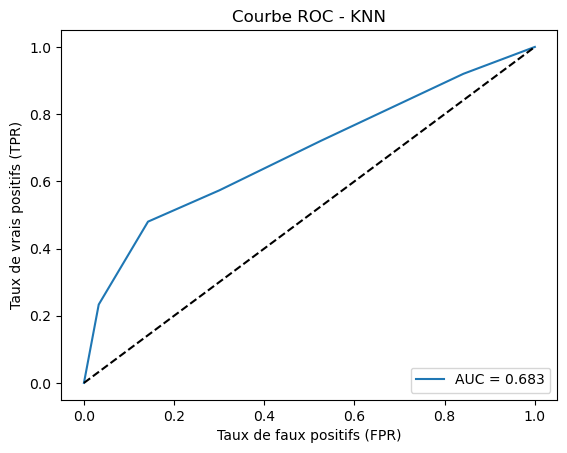


🔹 KNN Results:
Accuracy : 0.643
Recall   : 0.573
Precision: 0.610
Final score ((Accuracy + precision)/2) = 0.626
AUC : 0.683

 Entraînement du modèle : MLP


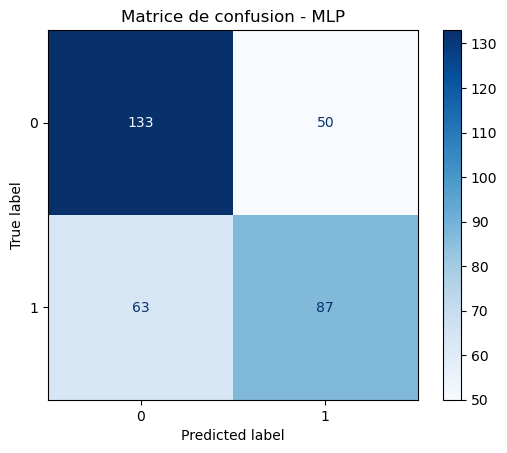

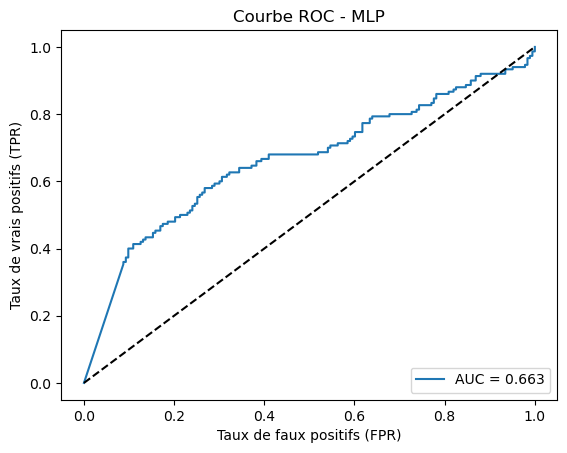


🔹 MLP Results:
Accuracy : 0.661
Recall   : 0.580
Precision: 0.635
Final score ((Accuracy + precision)/2) = 0.648
AUC : 0.663


=== Résumé des scores ===
CART: Final Score = 0.690 | Accuracy=0.712 | Precesion=0.669 | AUC=0.712
KNN: Final Score = 0.626 | Accuracy=0.643 | Precesion=0.610 | AUC=0.683
MLP: Final Score = 0.648 | Accuracy=0.661 | Precesion=0.635 | AUC=0.663

 Meilleur modèle : CART avec un score final de 0.690


In [112]:
# Exécution de run_classifiers sur les données non normalisées
# La fonction evaluate_model inclut déjà l'AUC
print("="*70)
print("RÉSULTATS SUR DONNÉES NON NORMALISÉES")
print("="*70)

best_model_credit, results_credit = run_classifiers_train_test(
    classifiers, 
    X_train_credit, 
    y_train_credit, 
    X_test_credit, 
    y_test_credit
)



## 3. Normalisation des variables continues


In [113]:
# Normalisation avec StandardScaler
scaler_std = StandardScaler()
X_train_credit_scaled_std = scaler_std.fit_transform(X_train_credit)
X_test_credit_scaled_std = scaler_std.transform(X_test_credit)

print("=== Normalisation avec StandardScaler ===")
print("Moyenne après normalisation (train):", np.mean(X_train_credit_scaled_std, axis=0))
print("Écart-type après normalisation (train):", np.std(X_train_credit_scaled_std, axis=0))


=== Normalisation avec StandardScaler ===
Moyenne après normalisation (train): [-0.  0. -0.  0. -0.  0.]
Écart-type après normalisation (train): [1. 1. 1. 1. 1. 1.]


RÉSULTATS SUR DONNÉES NORMALISÉES (StandardScaler)

 Entraînement du modèle : CART


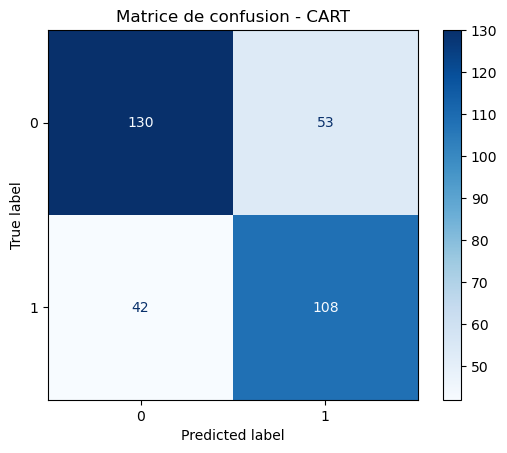

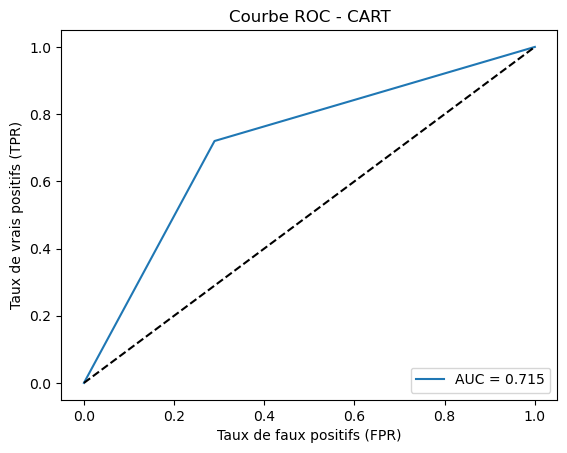


🔹 CART Results:
Accuracy : 0.715
Recall   : 0.720
Precision: 0.671
Final score ((Accuracy + precision)/2) = 0.693
AUC : 0.715

 Entraînement du modèle : KNN


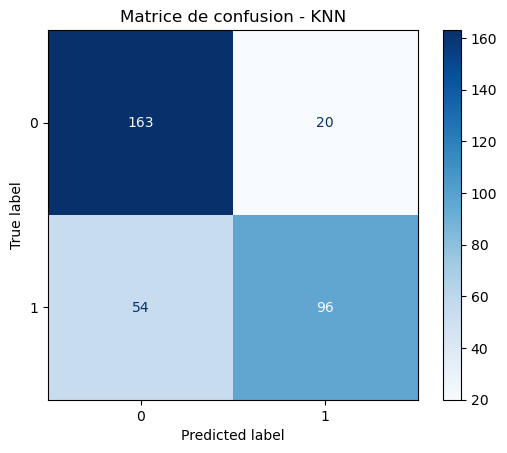

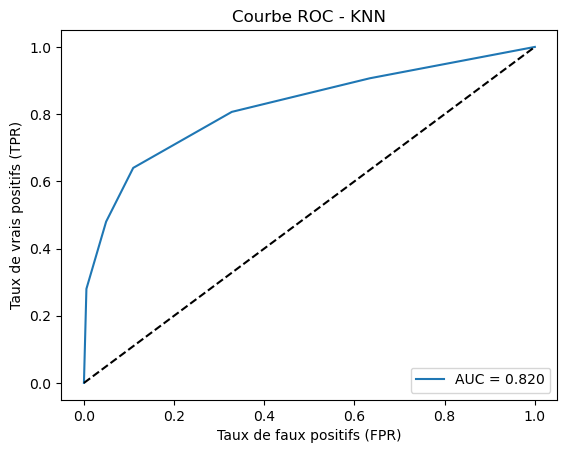


🔹 KNN Results:
Accuracy : 0.778
Recall   : 0.640
Precision: 0.828
Final score ((Accuracy + precision)/2) = 0.803
AUC : 0.820

 Entraînement du modèle : MLP


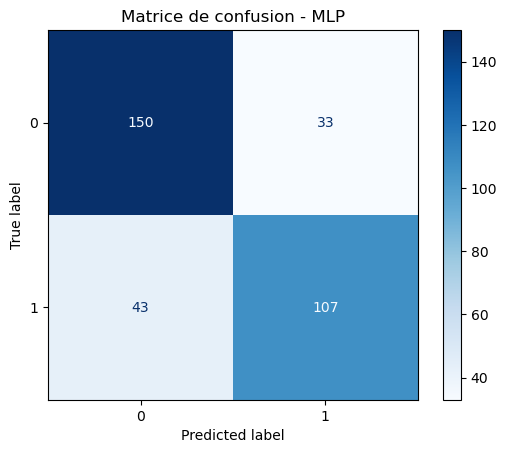

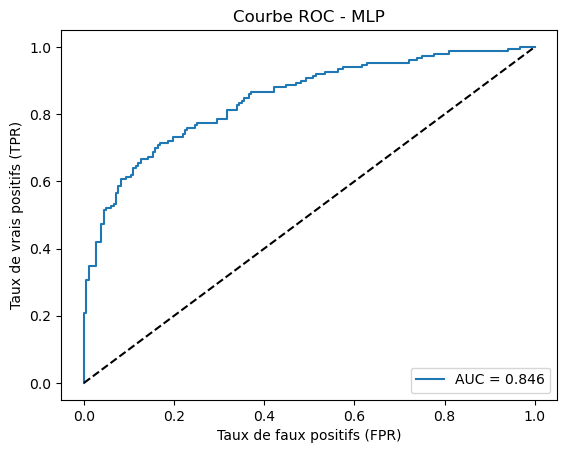


🔹 MLP Results:
Accuracy : 0.772
Recall   : 0.713
Precision: 0.764
Final score ((Accuracy + precision)/2) = 0.768
AUC : 0.846


=== Résumé des scores ===
CART: Final Score = 0.693 | Accuracy=0.715 | Precesion=0.671 | AUC=0.715
KNN: Final Score = 0.803 | Accuracy=0.778 | Precesion=0.828 | AUC=0.820
MLP: Final Score = 0.768 | Accuracy=0.772 | Precesion=0.764 | AUC=0.846

 Meilleur modèle : KNN avec un score final de 0.803


In [114]:
# Exécution de run_classifiers sur les données normalisées avec StandardScaler
print("="*70)
print("RÉSULTATS SUR DONNÉES NORMALISÉES (StandardScaler)")
print("="*70)

best_model_credit_scaled_std, results_credit_scaled_std = run_classifiers_train_test(
    classifiers, 
    X_train_credit_scaled_std, 
    y_train_credit, 
    X_test_credit_scaled_std, 
    y_test_credit
)



In [115]:
# Comparaison des résultats avant et après normalisation
print("="*70)
print("COMPARAISON DES RÉSULTATS")
print("="*70)

print("\n RÉSULTATS SANS NORMALISATION:")
for name, metrics in results_credit.items():
    print(f"  {name}: Accuracy={metrics['accuracy']:.3f} | Precision={metrics['precision']:.3f} | AUC={metrics['auc']:.3f}")

print("\n RÉSULTATS AVEC StandardScaler:")
for name, metrics in results_credit_scaled_std.items():
    print(f"  {name}: Accuracy={metrics['accuracy']:.3f} | Precision={metrics['precision']:.3f} | AUC={metrics['auc']:.3f}")


# Tableau comparatif
print("\n" + "="*70)
print("TABLEAU COMPARATIF - AUC")
print("="*70)
print(f"{'Modèle':<10} {'Sans norm.':<12} {'StandardScaler':<15}")
print("-" * 70)
for name in classifiers.keys():
    auc_no = results_credit[name]['auc']
    auc_std = results_credit_scaled_std[name]['auc']
    print(f"{name:<10} {auc_no:<12.3f} {auc_std:<15.3f}")




COMPARAISON DES RÉSULTATS

 RÉSULTATS SANS NORMALISATION:
  CART: Accuracy=0.712 | Precision=0.669 | AUC=0.712
  KNN: Accuracy=0.643 | Precision=0.610 | AUC=0.683
  MLP: Accuracy=0.661 | Precision=0.635 | AUC=0.663

 RÉSULTATS AVEC StandardScaler:
  CART: Accuracy=0.715 | Precision=0.671 | AUC=0.715
  KNN: Accuracy=0.778 | Precision=0.828 | AUC=0.820
  MLP: Accuracy=0.772 | Precision=0.764 | AUC=0.846

TABLEAU COMPARATIF - AUC
Modèle     Sans norm.   StandardScaler 
----------------------------------------------------------------------
CART       0.712        0.715          
KNN        0.683        0.820          
MLP        0.663        0.846          


Les résultats montrent que la normalisation a un effet significatif, en particulier sur KNN et MLP. Sans normalisation, KNN obtenait une accuracy de 0.643 et un AUC de 0.683, tandis qu’après normalisation, ces valeurs montent respectivement à 0.778 et 0.820, ce qui représente une amélioration très nette. De même, le MLP passe d’une accuracy de 0.661 à 0.772, et d’un AUC de 0.663 à 0.846, confirmant que les réseaux de neurones bénéficient fortement d’une mise à l’échelle des données. En comparaison, l’arbre de décision (CART) est très peu affecté : ses performances restent quasi identiques avant et après normalisation (AUC de 0.712 → 0.715), ce qui est logique puisque les arbres ne sont pas sensibles à l’échelle des variables.

Globalement, après normalisation, le meilleur modèle devient KNN avec un score final de 0.803, contre CART avant normalisation. Cette comparaison confirme que la normalisation améliore fortement les modèles basés sur les distances ou les gradients, alors qu’elle a peu d’effet sur les modèles arborescents. Cela montre l’importance d’adapter le prétraitement des données au type d’algorithmes utilisés.

## 4. Traitement de données manquantes


Shapes - X_full: (688, 15) | y_full_bin: (688,)
Numériques imputés - shape: (688, 6)
NaN restants num: 0
Catégorielles imputées - shape: (688, 9)
Valeurs -1 restantes cat: 0
Catégorielles binarisées - shape: (688, 40)
X_final shape: (688, 46)
Train/Test shapes: (344, 46) (344, 46)

RÉSULTATS SUR DONNÉES COMPLÈTES

 Entraînement du modèle : CART


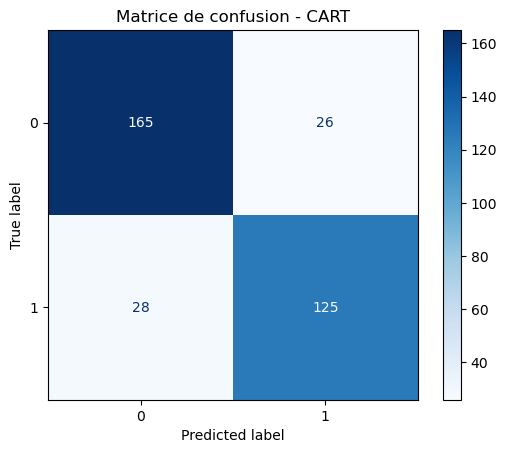

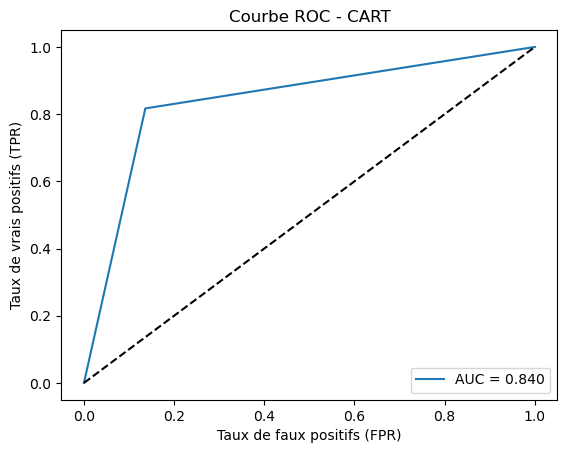


🔹 CART Results:
Accuracy : 0.843
Recall   : 0.817
Precision: 0.828
Final score ((Accuracy + precision)/2) = 0.835
AUC : 0.840

 Entraînement du modèle : KNN


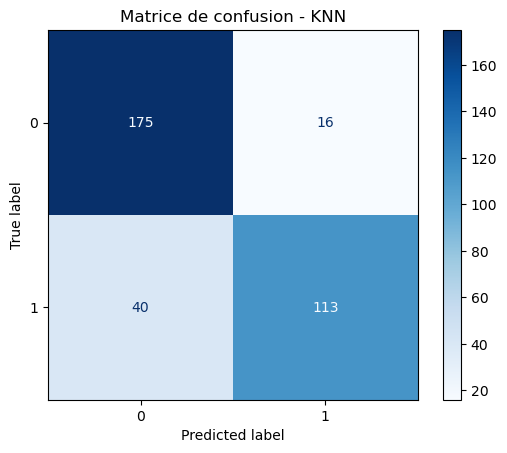

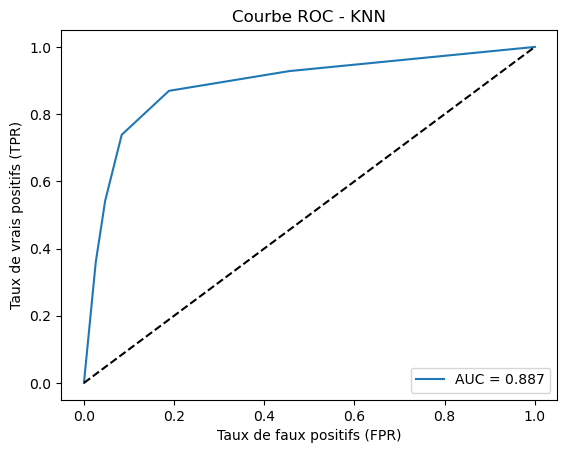


🔹 KNN Results:
Accuracy : 0.837
Recall   : 0.739
Precision: 0.876
Final score ((Accuracy + precision)/2) = 0.857
AUC : 0.887

 Entraînement du modèle : MLP


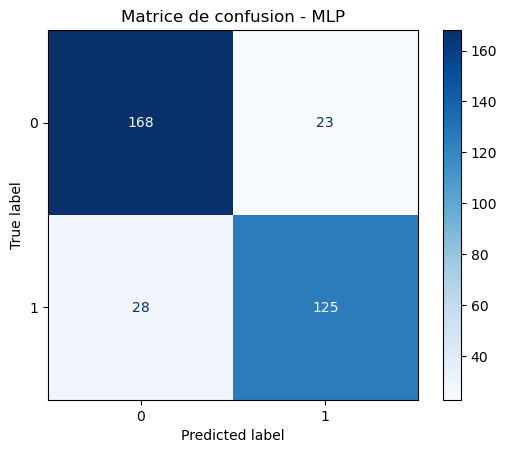

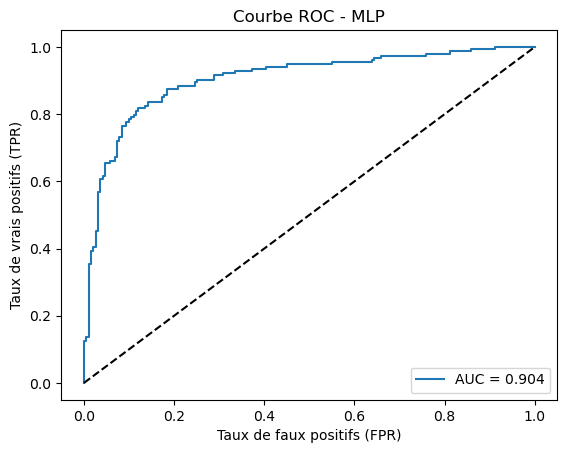


🔹 MLP Results:
Accuracy : 0.852
Recall   : 0.817
Precision: 0.845
Final score ((Accuracy + precision)/2) = 0.848
AUC : 0.904


=== Résumé des scores ===
CART: Final Score = 0.835 | Accuracy=0.843 | Precesion=0.828 | AUC=0.840
KNN: Final Score = 0.857 | Accuracy=0.837 | Precesion=0.876 | AUC=0.887
MLP: Final Score = 0.848 | Accuracy=0.852 | Precesion=0.845 | AUC=0.904

 Meilleur modèle : KNN avec un score final de 0.857

Résumé AUC (données complètes imputées + OHE + num normalisées) :
CART: Acc=0.843 | Prec=0.828 | AUC=0.840
KNN: Acc=0.837 | Prec=0.876 | AUC=0.887
MLP: Acc=0.852 | Prec=0.845 | AUC=0.904


In [116]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Préparation des colonnes et de la cible (15 variables complètes)
# Numériques (6) et catégorielles (9)
col_num = [1, 2, 7, 10, 13, 14]
col_cat = [0, 3, 4, 5, 6, 8, 9, 11, 12]

# X complet et cible binaire
X_full = arr_credit[:, :-1]
y_full = arr_credit[:, -1]
y_full_bin = (y_full == '+').astype(int)

print("Shapes - X_full:", X_full.shape, "| y_full_bin:", y_full_bin.shape)

# Imputation des variables numériques (mean)
X_num = np.copy(X_full[:, col_num])
X_num[X_num == '?'] = np.nan
X_num = X_num.astype(float)

imp_num = SimpleImputer(missing_values=np.nan, strategy='mean')
X_num_imputed = imp_num.fit_transform(X_num)

print("Numériques imputés - shape:", X_num_imputed.shape)
print("NaN restants num:", np.isnan(X_num_imputed).sum())

# Encodage ordinal + imputation des variables catégorielles (most_frequent)
X_cat = np.copy(X_full[:, col_cat])

# Encodage colonne par colonne en entiers, en gardant -1 pour les manquants
X_cat_enc = np.zeros_like(X_cat, dtype=float)
for j in range(X_cat.shape[1]):
    col_vals = X_cat[:, j]
    mask_nan = (col_vals == '?')
    col_vals_clean = col_vals.copy()
    col_vals_clean[mask_nan] = "_MISSING_"
    unique_vals, val_idx = np.unique(col_vals_clean, return_inverse=True)
    val_idx[mask_nan] = -1  # code -1 pour les manquants
    X_cat_enc[:, j] = val_idx

imp_cat = SimpleImputer(missing_values=-1, strategy='most_frequent')
X_cat_imputed = imp_cat.fit_transform(X_cat_enc)

print("Catégorielles imputées - shape:", X_cat_imputed.shape)
print("Valeurs -1 restantes cat:", np.sum(X_cat_imputed == -1))
                                                                                 
try:
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
except TypeError:
    ohe = OneHotEncoder(sparse=False, handle_unknown='ignore')  # fallback anciennes versions
X_cat_bin = ohe.fit_transform(X_cat_imputed)

print("Catégorielles binarisées - shape:", X_cat_bin.shape)

# Normalisation des numériques et construction du jeu final
scaler_full = StandardScaler()
X_num_scaled = scaler_full.fit_transform(X_num_imputed)

# Concaténation : numériques normalisés + catégorielles binarisées
X_final = np.concatenate([X_num_scaled, X_cat_bin], axis=1)
print("X_final shape:", X_final.shape)
      
      
# Split train/test et exécution des classifieurs
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_final, y_full_bin, test_size=0.5, random_state=1, stratify=y_full_bin
)

print("Train/Test shapes:", X_train_full.shape, X_test_full.shape)

print("\n==============================")
print("RÉSULTATS SUR DONNÉES COMPLÈTES")
print("==============================")
best_model_full, results_full = run_classifiers_train_test(
    classifiers,
    X_train_full,
    y_train_full,
    X_test_full,
    y_test_full
)

print("\nRésumé AUC (données complètes imputées + OHE + num normalisées) :")
for name, metrics in results_full.items():
    print(f"{name}: Acc={metrics['accuracy']:.3f} | Prec={metrics['precision']:.3f} | AUC={metrics['auc']:.3f}")
    

Les résultats montrent que tous les modèles ont obtenu de bonnes performances globales. Le CART atteint un score final de 0,835 avec une AUC de 0,840, indiquant un modèle simple mais relativement efficace. Le KNN présente le meilleur score final (0,857) et un AUC de 0,887, ce qui démontre que la normalisation des données a permis à cet algorithme sensible à l’échelle des variables de mieux exploiter les distances entre instances. Le MLP affiche un score final de 0,848 avec une AUC de 0,904, confirmant que les réseaux de neurones peuvent capturer des relations complexes dans les données.

En comparant les modèles, on constate que :

Le KNN est le plus performant sur le critère combiné (accuracy + précision), ce qui en fait le meilleur choix pour ce jeu de données.

Le MLP obtient la meilleure AUC, ce qui suggère qu’il est très efficace pour discriminer les classes positives et négatives malgré un score final légèrement inférieur au KNN.

Le CART, bien que légèrement moins performant, reste un modèle robuste et rapide à entraîner.

                                       FIN